# Experiment Dashboard: Latent-Space State–Action Mixup BC

**Protocol:** Compare four controlled Behavior Cloning augmentations on nine D4RL locomotion datasets. Evaluation uses a modern Gymnasium v5 simulator and is explicitly labeled a compatibility score, not the original D4RL v2 benchmark.

| Item | Default |
|---|---|
| Run mode | `SMOKE` |
| Methods | Vanilla, training noise, input mixup, latent mixup |
| Full matrix | 9 datasets × 4 methods × 5 seeds = 180 runs |
| OOD noise | 0, .01, .05, .10, .20 normalized units |
| Artifact root | `/kaggle/working/latent_mixup_bc` |

Run top-to-bottom. First complete `SMOKE`; publish the artifact directory as a Kaggle Dataset, attach it in the next session, set `RESUME_INPUT_ROOT`, then use `FULL_BENCHMARK`.

## Dependency Diagnostics

- **Purpose:** Install and verify the Python 3.12-compatible modern backend.
- **Inputs:** Kaggle Internet and Python image.
- **Outputs:** Imported PyTorch, Gymnasium, native MuJoCo, and data libraries.
- **Modes:** All
- **Cost:** minutes
- **Recovery:** Restart the session after installation if imports resolve to stale pre-install packages.


In [6]:
# SECTION: dependencies
import importlib.util, subprocess, sys

required = {
    "torch": "torch",
    "numpy": "numpy",
    "pandas": "pandas",
    "h5py": "h5py",
    "matplotlib": "matplotlib",
    "gymnasium": "gymnasium[mujoco]>=1.1",
    "mujoco": "mujoco>=3.2",
}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

import torch, numpy as np, pandas as pd
import gymnasium as gym, mujoco
gpu = None
if torch.cuda.is_available():
    gpu = {"name": torch.cuda.get_device_name(0), "capability": torch.cuda.get_device_capability(0), "torch_arches": torch.cuda.get_arch_list()}
print({"python": sys.version, "torch": torch.__version__, "cuda": torch.cuda.is_available(), "gpu": gpu, "gymnasium": gym.__version__, "mujoco": mujoco.__version__})
print("For GPU training, choose a Kaggle T4 accelerator. A P100 may fall back to CPU with current PyTorch wheels.")


{'python': '3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]', 'torch': '2.10.0+cu128', 'cuda': True, 'gpu': {'name': 'Tesla T4', 'capability': (7, 5), 'torch_arches': ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']}, 'gymnasium': '1.2.0', 'mujoco': '3.10.0'}
For GPU training, choose a Kaggle T4 accelerator. A P100 may fall back to CPU with current PyTorch wheels.


## Configuration

- **Purpose:** Create the frozen benchmark matrix and safe run mode.
- **Inputs:** User-selected mode/single-run fields.
- **Outputs:** ExperimentConfig, run list, config hash, output paths.
- **Modes:** All
- **Cost:** seconds
- **Recovery:** Correct configuration fields and rerun; stale hashes are not resumed.


In [7]:
# SECTION: configuration package
from pathlib import Path
Path('latent_mixup_bc').mkdir(exist_ok=True)
Path('latent_mixup_bc/__init__.py').write_text('')


0

## %%Writefile Latent_Mixup_Bc/Config.Py (continued)

- **Purpose:** Continue the preceding section with one independently rerunnable unit.
- **Inputs:** Objects and files produced by the preceding cell.
- **Outputs:** Updated module or runtime state for the next cell.
- **Modes:** All
- **Cost:** seconds to minutes
- **Recovery:** Rerun the preceding cell, then rerun this unit; durable artifacts are not deleted.


In [8]:
%%writefile latent_mixup_bc/config.py
# SECTION: configuration package
"""Frozen experiment configuration and benchmark enumeration."""

from __future__ import annotations

from dataclasses import asdict, dataclass
from hashlib import sha256
import json
from typing import Optional, Tuple


ENVIRONMENTS = ("hopper", "halfcheetah", "walker2d")
QUALITIES = ("medium", "medium-replay", "medium-expert")
METHODS = ("vanilla_bc", "noise_bc", "input_mixup_bc", "latent_mixup_bc")
SEEDS = (0, 1, 2, 3, 4)
MODES = ("SMOKE", "SINGLE_RUN", "FULL_BENCHMARK")


@dataclass(frozen=True)
class ExperimentConfig:
    mode: str = "SMOKE"
    environments: Tuple[str, ...] = ENVIRONMENTS
    qualities: Tuple[str, ...] = QUALITIES
    methods: Tuple[str, ...] = METHODS
    seeds: Tuple[int, ...] = SEEDS
    noise_levels: Tuple[float, ...] = (0.0, 0.01, 0.05, 0.10, 0.20)
    batch_size: int = 256
    learning_rate: float = 3e-4
    latent_dim: int = 128
    mixup_alpha: float = 0.2
    training_noise_std: float = 0.05
    max_epochs: int = 100
    patience: int = 10
    validation_fraction: float = 0.1
    evaluation_episodes: int = 20
    hidden_dim: int = 256
    weight_decay: float = 0.0
    smoke_max_transitions: int = 10_000
    single_dataset: Optional[str] = None
    single_method: Optional[str] = None
    single_seed: Optional[int] = None

    def __post_init__(self) -> None:
        if self.mode not in MODES:
            raise ValueError(f"mode must be one of {MODES}, got {self.mode!r}")
        if not 0.0 < self.validation_fraction < 1.0:
            raise ValueError("validation_fraction must be between 0 and 1")
        if self.batch_size <= 0 or self.max_epochs <= 0 or self.evaluation_episodes <= 0:
            raise ValueError("batch_size, max_epochs, and evaluation_episodes must be positive")
        if self.mode == "SINGLE_RUN":
            if self.single_dataset is None or self.single_method is None or self.single_seed is None:
                raise ValueError("SINGLE_RUN requires single_dataset, single_method, and single_seed")


@dataclass(frozen=True)
class RunSpec:
    dataset_id: str
    env_id: str
    method: str
    seed: int


def _dataset_id(environment: str, quality: str) -> str:
    return f"{environment}-{quality}-v2"


def _env_id(environment: str) -> str:
    names = {"hopper": "Hopper-v5", "halfcheetah": "HalfCheetah-v5", "walker2d": "Walker2d-v5"}
    return names[environment]


def enumerate_runs(config: ExperimentConfig):
    if config.mode == "SMOKE":
        dataset_id = _dataset_id(config.environments[0], config.qualities[0])
        return tuple(
            RunSpec(dataset_id, _env_id(config.environments[0]), method, config.seeds[0])
            for method in config.methods
        )
    if config.mode == "SINGLE_RUN":
        dataset_id = str(config.single_dataset)
        environment = dataset_id.split("-")[0]
        return (RunSpec(dataset_id, _env_id(environment), str(config.single_method), int(config.single_seed)),)
    return tuple(
        RunSpec(_dataset_id(environment, quality), _env_id(environment), method, seed)
        for environment in config.environments
        for quality in config.qualities
        for method in config.methods
        for seed in config.seeds
    )


def config_hash(config: ExperimentConfig) -> str:
    payload = json.dumps(asdict(config), sort_keys=True, separators=(",", ":"))
    return sha256(payload.encode("utf-8")).hexdigest()[:12]


Overwriting latent_mixup_bc/config.py


## Configuration (continued)

- **Purpose:** Continue the preceding section with one independently rerunnable unit.
- **Inputs:** Objects and files produced by the preceding cell.
- **Outputs:** Updated module or runtime state for the next cell.
- **Modes:** All
- **Cost:** seconds to minutes
- **Recovery:** Rerun the preceding cell, then rerun this unit; durable artifacts are not deleted.


In [9]:
# SECTION: configuration
from latent_mixup_bc.config import ExperimentConfig, enumerate_runs, config_hash

RUN_MODE = "SINGLE_RUN" # SMOKE | SINGLE_RUN | FULL_BENCHMARK
SINGLE_DATASET = "hopper-medium-v2"
SINGLE_METHOD = "vanilla_bc"
SINGLE_SEED = 0
RESUME_INPUT_ROOT = None  # e.g. /kaggle/input/previous-run/latent_mixup_bc
OUTPUT_ROOT = Path("/kaggle/working/latent_mixup_bc") if Path("/kaggle").exists() else Path("artifacts/latent_mixup_bc")

config = ExperimentConfig(
    mode=RUN_MODE,
    single_dataset=SINGLE_DATASET if RUN_MODE == "SINGLE_RUN" else None,
    single_method=SINGLE_METHOD if RUN_MODE == "SINGLE_RUN" else None,
    single_seed=SINGLE_SEED if RUN_MODE == "SINGLE_RUN" else None,
)
runs = enumerate_runs(config)
if RUN_MODE == "FULL_BENCHMARK":
    assert len(runs) == 180
print({"mode": RUN_MODE, "jobs": len(runs), "config_hash": config_hash(config), "output": str(OUTPUT_ROOT)})


{'mode': 'SINGLE_RUN', 'jobs': 1, 'config_hash': '202d57351441', 'output': '/kaggle/working/latent_mixup_bc'}


## Reproducibility and Self-Tests

- **Purpose:** Materialize tested core modules and catch semantic regressions before costly work.
- **Inputs:** Canonical embedded module source.
- **Outputs:** Importable package and passing assertions.
- **Modes:** All
- **Cost:** seconds
- **Recovery:** Fix the failing assertion; do not proceed to data or training.


In [10]:
%%writefile latent_mixup_bc/data.py
# SECTION: data module
"""Validated D4RL loading and leakage-safe preprocessing."""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Mapping, Sequence

import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset


REQUIRED_KEYS = ("observations", "actions", "terminals", "timeouts")


def validate_dataset(dataset: Mapping[str, np.ndarray]) -> None:
    missing = [key for key in REQUIRED_KEYS if key not in dataset]
    if missing:
        raise ValueError(f"D4RL dataset is missing required keys: {missing}")
    arrays = {key: np.asarray(dataset[key]) for key in REQUIRED_KEYS}
    n = len(arrays["observations"])
    if n == 0:
        raise ValueError("D4RL dataset contains no transitions")
    if arrays["observations"].ndim != 2 or arrays["actions"].ndim != 2:
        raise ValueError("observations and actions must both be rank-2 arrays")
    bad_lengths = {key: len(value) for key, value in arrays.items() if len(value) != n}
    if bad_lengths:
        raise ValueError(f"D4RL arrays have inconsistent lengths: expected {n}, got {bad_lengths}")
    if not np.isfinite(arrays["observations"]).all():
        raise ValueError("observations contain NaN or infinite values")
    if not np.isfinite(arrays["actions"]).all():
        raise ValueError("actions contain NaN or infinite values")


def trajectory_ranges(terminals: np.ndarray, timeouts: np.ndarray):
    terminals = np.asarray(terminals, dtype=bool).reshape(-1)
    timeouts = np.asarray(timeouts, dtype=bool).reshape(-1)
    if len(terminals) != len(timeouts):
        raise ValueError("terminals and timeouts must have equal lengths")
    ranges = []
    start = 0
    for index, ended in enumerate(terminals | timeouts):
        if ended:
            ranges.append((start, index + 1))
            start = index + 1
    if start < len(terminals):
        ranges.append((start, len(terminals)))
    return ranges


def split_trajectories(
    ranges: Sequence[tuple[int, int]], valid_fraction: float, seed: int
):
    if not 0.0 < valid_fraction < 1.0:
        raise ValueError("valid_fraction must be between 0 and 1")
    if len(ranges) < 2:
        raise ValueError("at least two trajectories are required for a disjoint split")
    order = np.random.default_rng(seed).permutation(len(ranges))
    n_valid = min(len(ranges) - 1, max(1, int(round(len(ranges) * valid_fraction))))
    valid_trajectories = set(order[:n_valid].tolist())
    train_rows, valid_rows = [], []
    for index, (start, stop) in enumerate(ranges):
        target = valid_rows if index in valid_trajectories else train_rows
        target.extend(range(start, stop))
    return train_rows, valid_rows


@dataclass(frozen=True)
class StateNormalizer:
    mean: np.ndarray
    std: np.ndarray

    @classmethod
    def fit(cls, states: np.ndarray) -> "StateNormalizer":
        states = np.asarray(states, dtype=np.float32)
        if states.ndim != 2 or len(states) == 0:
            raise ValueError("training states must be a non-empty rank-2 array")
        mean = states.mean(axis=0, dtype=np.float64).astype(np.float32)
        std = states.std(axis=0, dtype=np.float64).astype(np.float32)
        std = np.where(std < 1e-6, 1.0, std).astype(np.float32)
        return cls(mean=mean, std=std)

    def transform(self, states: np.ndarray) -> np.ndarray:
        return ((np.asarray(states, dtype=np.float32) - self.mean) / self.std).astype(np.float32)

    def to_dict(self):
        return {"mean": self.mean.tolist(), "std": self.std.tolist()}

    @classmethod
    def from_dict(cls, payload):
        return cls(np.asarray(payload["mean"], dtype=np.float32), np.asarray(payload["std"], dtype=np.float32))


def load_d4rl_hdf5(path: str | Path):
    try:
        import h5py
    except ImportError as exc:
        raise RuntimeError("h5py is required to read cached D4RL datasets") from exc
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"D4RL HDF5 file not found: {path}")
    with h5py.File(path, "r") as handle:
        dataset = {key: np.asarray(handle[key]) for key in REQUIRED_KEYS if key in handle}
    validate_dataset(dataset)
    return dataset


def make_loaders(
    dataset: Mapping[str, np.ndarray], batch_size: int, valid_fraction: float, seed: int,
    max_transitions: int | None = None,
):
    validate_dataset(dataset)
    ranges = trajectory_ranges(dataset["terminals"], dataset["timeouts"])
    train_rows, valid_rows = split_trajectories(ranges, valid_fraction, seed)
    if max_transitions is not None:
        train_rows = train_rows[:max_transitions]
        valid_rows = valid_rows[:max(1, max_transitions // 10)]
    observations = np.asarray(dataset["observations"], dtype=np.float32)
    actions = np.asarray(dataset["actions"], dtype=np.float32)
    normalizer = StateNormalizer.fit(observations[train_rows])

    def loader(rows, shuffle):
        states = torch.from_numpy(normalizer.transform(observations[rows]))
        targets = torch.from_numpy(actions[rows].astype(np.float32))
        generator = torch.Generator().manual_seed(seed)
        return DataLoader(
            TensorDataset(states, targets), batch_size=batch_size, shuffle=shuffle,
            generator=generator if shuffle else None,
        )

    return loader(train_rows, True), loader(valid_rows, False), normalizer, train_rows, valid_rows


Overwriting latent_mixup_bc/data.py


## %%Writefile Latent_Mixup_Bc/Benchmark.Py (continued)

- **Purpose:** Continue the preceding section with one independently rerunnable unit.
- **Inputs:** Objects and files produced by the preceding cell.
- **Outputs:** Updated module or runtime state for the next cell.
- **Modes:** All
- **Cost:** seconds to minutes
- **Recovery:** Rerun the preceding cell, then rerun this unit; durable artifacts are not deleted.


In [11]:
%%writefile latent_mixup_bc/benchmark.py
# SECTION: benchmark compatibility module
"""D4RL dataset locations and explicitly non-standard modern-simulator scoring."""

from __future__ import annotations


DATASET_BASE_URL = "https://rail.eecs.berkeley.edu/datasets/offline_rl/gym_mujoco_v2"
MODERN_ENVS = {
    "hopper": "Hopper-v5",
    "halfcheetah": "HalfCheetah-v5",
    "walker2d": "Walker2d-v5",
}
REFERENCE_SCORES = {
    "hopper": (-20.272305, 3234.3),
    "halfcheetah": (-280.178953, 12135.0),
    "walker2d": (1.629008, 4592.3),
}
METRIC_LABEL = "modern_simulator_compatibility_score"


def environment_name(dataset_id: str) -> str:
    name = dataset_id.split("-", 1)[0]
    if name not in MODERN_ENVS:
        raise ValueError(f"unsupported locomotion dataset: {dataset_id!r}")
    return name


def modern_env_id(dataset_id: str) -> str:
    return MODERN_ENVS[environment_name(dataset_id)]


def dataset_url(dataset_id: str) -> str:
    if not dataset_id.endswith("-v2"):
        raise ValueError(f"expected a D4RL v2 dataset ID, got {dataset_id!r}")
    environment_name(dataset_id)
    filename = dataset_id[:-3].replace("-", "_") + "-v2.hdf5"
    return f"{DATASET_BASE_URL}/{filename}"


def compatibility_score(dataset_id: str, raw_return: float) -> float:
    minimum, maximum = REFERENCE_SCORES[environment_name(dataset_id)]
    return 100.0 * (float(raw_return) - minimum) / (maximum - minimum)


Writing latent_mixup_bc/benchmark.py


## %%Writefile Latent_Mixup_Bc/Models.Py (continued)

- **Purpose:** Continue the preceding section with one independently rerunnable unit.
- **Inputs:** Objects and files produced by the preceding cell.
- **Outputs:** Updated module or runtime state for the next cell.
- **Modes:** All
- **Cost:** seconds to minutes
- **Recovery:** Rerun the preceding cell, then rerun this unit; durable artifacts are not deleted.


In [12]:
%%writefile latent_mixup_bc/models.py
# SECTION: Models and Augmentation
"""Controlled BC architecture and explicit augmentation transformations."""

from __future__ import annotations

from dataclasses import dataclass

import torch
from torch import nn


METHODS = ("vanilla_bc", "noise_bc", "input_mixup_bc", "latent_mixup_bc")


class BCPolicy(nn.Module):
    def __init__(
        self, state_dim: int, action_dim: int, latent_dim: int = 128, hidden_dim: int = 256
    ) -> None:
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
        )
        self.policy_head = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def encode(self, states: torch.Tensor) -> torch.Tensor:
        return self.encoder(states)

    def act_from_latent(self, latent: torch.Tensor) -> torch.Tensor:
        return self.policy_head(latent)

    def forward(self, states: torch.Tensor) -> torch.Tensor:
        return self.act_from_latent(self.encode(states))


@dataclass(frozen=True)
class MixupBatch:
    representation: torch.Tensor
    target: torch.Tensor
    lambda_: torch.Tensor
    permutation: torch.Tensor


def sample_mixup(reference: torch.Tensor, alpha: float = 0.2):
    batch_size = reference.shape[0]
    if batch_size == 0:
        raise ValueError("cannot mix an empty batch")
    if alpha <= 0:
        lam = torch.ones(batch_size, device=reference.device, dtype=reference.dtype)
    else:
        concentration = torch.tensor(alpha, device=reference.device, dtype=reference.dtype)
        lam = torch.distributions.Beta(concentration, concentration).sample((batch_size,))
    permutation = torch.randperm(batch_size, device=reference.device)
    return lam, permutation


def _mix(values: torch.Tensor, lam: torch.Tensor, permutation: torch.Tensor):
    shape = (values.shape[0],) + (1,) * (values.ndim - 1)
    weight = lam.reshape(shape)
    return weight * values + (1.0 - weight) * values[permutation]


def prepare_training_batch(
    method: str,
    representation: torch.Tensor,
    actions: torch.Tensor,
    *,
    alpha: float = 0.2,
    noise_std: float = 0.05,
    lam: torch.Tensor | None = None,
    permutation: torch.Tensor | None = None,
    representation_is_latent: bool = False,
) -> MixupBatch:
    if method not in METHODS:
        raise ValueError(f"unknown method: {method!r}")
    batch_size = representation.shape[0]
    if actions.shape[0] != batch_size:
        raise ValueError("representation and actions must have the same batch size")
    identity_lam = torch.ones(batch_size, device=representation.device, dtype=representation.dtype)
    identity_perm = torch.arange(batch_size, device=representation.device)

    if method == "vanilla_bc":
        return MixupBatch(representation, actions, identity_lam, identity_perm)
    if method == "noise_bc":
        if representation_is_latent:
            raise ValueError("noise_bc noise must be applied to normalized input states")
        noisy = representation + noise_std * torch.randn_like(representation)
        return MixupBatch(noisy, actions, identity_lam, identity_perm)

    if method == "latent_mixup_bc" and not representation_is_latent:
        raise ValueError("latent_mixup_bc requires encoded representations")
    if method == "input_mixup_bc" and representation_is_latent:
        raise ValueError("input_mixup_bc requires normalized input states")

    if (lam is None) != (permutation is None):
        raise ValueError("lam and permutation must be supplied together")
    if lam is None:
        lam, permutation = sample_mixup(representation, alpha)
    lam = lam.to(device=representation.device, dtype=representation.dtype)
    permutation = permutation.to(device=representation.device, dtype=torch.long)
    if lam.shape != (batch_size,) or permutation.shape != (batch_size,):
        raise ValueError("lambda and permutation must each have shape [batch_size]")
    return MixupBatch(
        representation=_mix(representation, lam, permutation),
        target=_mix(actions, lam.to(actions.dtype), permutation),
        lambda_=lam,
        permutation=permutation,
    )


Writing latent_mixup_bc/models.py


## Self Tests (continued)

- **Purpose:** Continue the preceding section with one independently rerunnable unit.
- **Inputs:** Objects and files produced by the preceding cell.
- **Outputs:** Updated module or runtime state for the next cell.
- **Modes:** All
- **Cost:** seconds to minutes
- **Recovery:** Rerun the preceding cell, then rerun this unit; durable artifacts are not deleted.


In [13]:
# SECTION: self tests
import torch
from latent_mixup_bc.models import BCPolicy, prepare_training_batch

s = torch.tensor([[0.0], [10.0]])
a = torch.tensor([[1.0], [3.0]])
lam, perm = torch.tensor([.25, .75]), torch.tensor([1, 0])
mixed = prepare_training_batch("input_mixup_bc", s, a, lam=lam, permutation=perm)
assert torch.equal(mixed.permutation, perm)
assert torch.allclose(mixed.target, lam[:, None] * a + (1-lam[:, None]) * a[perm])
assert BCPolicy(11, 3)(torch.zeros(2, 11)).shape == (2, 3)
assert set(config.methods) == {"vanilla_bc", "noise_bc", "input_mixup_bc", "latent_mixup_bc"}
print("Core self-tests passed")


Core self-tests passed


## D4RL Data

- **Purpose:** Download original fixed D4RL v2 HDF5 data directly, reconstruct trajectories, and compute train-only statistics.
- **Inputs:** Kaggle Internet or cached HDF5.
- **Outputs:** Validated arrays, disjoint DataLoaders, StateNormalizer.
- **Modes:** All
- **Cost:** minutes
- **Recovery:** On download/data failure, attach the cached HDF5 files or repair Internet access; no generated fallback data.


In [14]:
# SECTION: D4RL Data
from urllib.request import urlretrieve
from latent_mixup_bc.benchmark import dataset_url
from latent_mixup_bc.data import load_d4rl_hdf5, make_loaders

def load_real_d4rl(dataset_id):
    cache_dir = OUTPUT_ROOT / "cache" / "d4rl_hdf5"
    cache_dir.mkdir(parents=True, exist_ok=True)
    path = cache_dir / f"{dataset_id}.hdf5"
    if not path.exists():
        temporary = path.with_suffix(".download")
        urlretrieve(dataset_url(dataset_id), temporary)
        temporary.replace(path)
    return load_d4rl_hdf5(path)

dataset_cache = {}
def prepared_data(run):
    if run.dataset_id not in dataset_cache:
        dataset_cache[run.dataset_id] = load_real_d4rl(run.dataset_id)
    cap = config.smoke_max_transitions if config.mode == "SMOKE" else None
    return make_loaders(dataset_cache[run.dataset_id], config.batch_size, config.validation_fraction, run.seed, cap)

sample = dataset_cache.setdefault(runs[0].dataset_id, load_real_d4rl(runs[0].dataset_id))
print(runs[0].dataset_id, sample["observations"].shape, sample["actions"].shape)


hopper-medium-v2 (1000000, 11) (1000000, 3)


## Training and Resume

- **Purpose:** Train fair ablations with early stopping and durable artifacts.
- **Inputs:** Prepared D4RL loaders, config, optional prior artifacts.
- **Outputs:** Checkpoints, histories, completion manifests.
- **Modes:** All
- **Cost:** expensive
- **Recovery:** Interrupted/incomplete jobs rerun; complete matching-hash jobs are skipped.


In [15]:
%%writefile latent_mixup_bc/persistence.py
# SECTION: persistence module
"""Atomic artifact persistence and cross-session resume checks."""

from __future__ import annotations

import json
import os
from pathlib import Path
import shutil
import tempfile

import pandas as pd
import torch


EPISODE_KEY = ["dataset_id", "method", "seed", "noise_std", "episode"]


def restore_missing_artifacts(source, destination):
    source, destination = Path(source), Path(destination)
    if not source.exists():
        raise FileNotFoundError(f"resume input root does not exist: {source}")
    copied = []
    for item in source.rglob("*"):
        if not item.is_file() or item.name.endswith(".tmp"):
            continue
        target = destination / item.relative_to(source)
        if target.exists():
            continue
        target.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(item, target)
        copied.append(target)
    return copied


class ArtifactStore:
    def __init__(self, root):
        self.root = Path(root)
        self.episode_results_path = self.root / "results" / "episode_results.csv"
        for directory in ("checkpoints", "histories", "manifests", "results", "figures", "cache"):
            (self.root / directory).mkdir(parents=True, exist_ok=True)

    def checkpoint_path(self, dataset_id, method, seed):
        return self.root / "checkpoints" / dataset_id / method / f"seed_{seed}.pth"

    def history_path(self, dataset_id, method, seed):
        return self.root / "histories" / dataset_id / method / f"seed_{seed}.csv"

    def manifest_path(self, dataset_id, method, seed):
        return self.root / "manifests" / dataset_id / method / f"seed_{seed}.json"

    @staticmethod
    def _temp_path(destination: Path):
        destination.parent.mkdir(parents=True, exist_ok=True)
        handle = tempfile.NamedTemporaryFile(prefix=destination.name + ".", suffix=".tmp", dir=destination.parent, delete=False)
        handle.close()
        return Path(handle.name)

    def save_checkpoint_atomic(self, dataset_id, method, seed, payload):
        destination = self.checkpoint_path(dataset_id, method, seed)
        temporary = self._temp_path(destination)
        try:
            torch.save(payload, temporary)
            os.replace(temporary, destination)
        finally:
            temporary.unlink(missing_ok=True)
        return destination

    def load_checkpoint(self, dataset_id, method, seed, map_location="cpu"):
        return torch.load(
            self.checkpoint_path(dataset_id, method, seed), map_location=map_location,
            weights_only=False,
        )

    def write_csv_atomic(self, frame: pd.DataFrame, destination: Path):
        temporary = self._temp_path(destination)
        try:
            frame.to_csv(temporary, index=False)
            os.replace(temporary, destination)
        finally:
            temporary.unlink(missing_ok=True)

    def write_json_atomic(self, payload, destination: Path):
        temporary = self._temp_path(destination)
        try:
            temporary.write_text(json.dumps(payload, indent=2, sort_keys=True), encoding="utf-8")
            os.replace(temporary, destination)
        finally:
            temporary.unlink(missing_ok=True)

    def upsert_episode_rows(self, rows: pd.DataFrame):
        if rows.empty:
            return
        missing = [key for key in EPISODE_KEY if key not in rows]
        if missing:
            raise ValueError(f"episode rows are missing key columns: {missing}")
        existing = pd.read_csv(self.episode_results_path) if self.episode_results_path.exists() else pd.DataFrame()
        combined = pd.concat([existing, rows], ignore_index=True)
        combined = combined.drop_duplicates(EPISODE_KEY, keep="last").sort_values(EPISODE_KEY)
        self.write_csv_atomic(combined, self.episode_results_path)

    def is_training_complete(self, run, expected_hash):
        manifest_path = self.manifest_path(run.dataset_id, run.method, run.seed)
        if not manifest_path.exists():
            return False
        try:
            manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
        except (OSError, json.JSONDecodeError):
            return False
        return (
            manifest.get("status") == "complete"
            and manifest.get("config_hash") == expected_hash
            and self.checkpoint_path(run.dataset_id, run.method, run.seed).exists()
            and self.history_path(run.dataset_id, run.method, run.seed).exists()
        )


Writing latent_mixup_bc/persistence.py


## %%Writefile Latent_Mixup_Bc/Train.Py (continued)

- **Purpose:** Continue the preceding section with one independently rerunnable unit.
- **Inputs:** Objects and files produced by the preceding cell.
- **Outputs:** Updated module or runtime state for the next cell.
- **Modes:** All
- **Cost:** seconds to minutes
- **Recovery:** Rerun the preceding cell, then rerun this unit; durable artifacts are not deleted.


In [16]:
%%writefile latent_mixup_bc/train.py
# SECTION: training module
"""Deterministic training and early stopping for the four BC methods."""

from __future__ import annotations

from dataclasses import asdict
import random
import re
import warnings

import numpy as np
import pandas as pd
import torch
from torch import nn

from .config import config_hash
from .models import BCPolicy, prepare_training_batch


def cuda_arch_supported(capability, arch_list):
    supported = []
    for architecture in arch_list:
        match = re.fullmatch(r"(?:sm|compute)_(\d+)", architecture)
        if match:
            supported.append(int(match.group(1)))
    if not supported:
        return False
    device_arch = int(capability[0]) * 10 + int(capability[1])
    return min(supported) <= device_arch <= max(supported)


def select_device(requested=None):
    if requested is not None and str(requested).startswith("cpu"):
        return torch.device("cpu")
    wants_cuda = requested is None or str(requested).startswith("cuda")
    if wants_cuda and torch.cuda.is_available():
        try:
            capability = torch.cuda.get_device_capability(0)
            architectures = torch.cuda.get_arch_list()
            if cuda_arch_supported(capability, architectures):
                return torch.device(requested or "cuda")
            warnings.warn(
                f"GPU capability sm_{capability[0]}{capability[1]} is not supported by this "
                f"PyTorch build ({architectures}); falling back to CPU. Select a Kaggle T4 "
                "accelerator for GPU training with the current image.",
                RuntimeWarning,
            )
        except Exception as exc:
            warnings.warn(f"CUDA compatibility check failed ({exc}); falling back to CPU.", RuntimeWarning)
    return torch.device("cpu")


def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def _training_prediction(model, method, states, actions, config):
    if method == "latent_mixup_bc":
        latent = model.encode(states)
        batch = prepare_training_batch(
            method, latent, actions, alpha=config.mixup_alpha, representation_is_latent=True
        )
        return model.act_from_latent(batch.representation), batch.target
    batch = prepare_training_batch(
        method, states, actions, alpha=config.mixup_alpha, noise_std=config.training_noise_std
    )
    return model(batch.representation), batch.target


@torch.no_grad()
def validation_mse(model, loader, device):
    criterion = nn.MSELoss(reduction="sum")
    loss_sum = 0.0
    element_count = 0
    model.eval()
    for states, actions in loader:
        states, actions = states.to(device), actions.to(device)
        prediction = model(states)
        loss_sum += criterion(prediction, actions).item()
        element_count += actions.numel()
    return loss_sum / max(1, element_count)


def train_one_run(run, config, train_loader, valid_loader, state_dim, action_dim, store, device=None, normalizer=None):
    run_hash = config_hash(config)
    if store.is_training_complete(run, run_hash):
        return {"status": "complete", "skipped": True}
    device = select_device(device)
    set_global_seed(run.seed)
    model = BCPolicy(state_dim, action_dim, config.latent_dim, config.hidden_dim).to(device)
    optimizer = torch.optim.Adam(
        model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay
    )
    criterion = nn.MSELoss()
    best_loss = float("inf")
    best_epoch = -1
    stale_epochs = 0
    history = []
    max_epochs = 2 if config.mode == "SMOKE" else config.max_epochs

    for epoch in range(max_epochs):
        model.train()
        loss_sum = 0.0
        batches = 0
        for states, actions in train_loader:
            states, actions = states.to(device), actions.to(device)
            optimizer.zero_grad(set_to_none=True)
            prediction, target = _training_prediction(model, run.method, states, actions, config)
            loss = criterion(prediction, target)
            if not torch.isfinite(loss):
                raise FloatingPointError(f"non-finite training loss for {run}")
            loss.backward()
            optimizer.step()
            loss_sum += loss.item()
            batches += 1
        valid_loss = validation_mse(model, valid_loader, device)
        history.append({"epoch": epoch + 1, "train_mse": loss_sum / max(1, batches), "valid_mse": valid_loss})
        if valid_loss < best_loss:
            best_loss, best_epoch, stale_epochs = valid_loss, epoch + 1, 0
            store.save_checkpoint_atomic(run.dataset_id, run.method, run.seed, {
                "model": model.state_dict(), "optimizer": optimizer.state_dict(),
                "config": asdict(config), "config_hash": run_hash,
                "state_dim": state_dim, "action_dim": action_dim,
                "best_epoch": best_epoch, "best_valid_mse": best_loss,
                "normalizer": normalizer.to_dict() if normalizer is not None else None,
            })
        else:
            stale_epochs += 1
            if stale_epochs >= config.patience:
                break

    history_path = store.history_path(run.dataset_id, run.method, run.seed)
    store.write_csv_atomic(pd.DataFrame(history), history_path)
    manifest_path = store.manifest_path(run.dataset_id, run.method, run.seed)
    store.write_json_atomic({
        "status": "complete", "config_hash": run_hash, "dataset_id": run.dataset_id,
        "env_id": run.env_id, "method": run.method, "seed": run.seed,
        "best_epoch": best_epoch, "best_valid_mse": best_loss,
        "checkpoint": str(store.checkpoint_path(run.dataset_id, run.method, run.seed)),
        "history": str(history_path),
    }, manifest_path)
    return {"status": "complete", "skipped": False, "best_epoch": best_epoch, "best_valid_mse": best_loss}


def load_best_policy(run, config, store, device="cpu"):
    payload = store.load_checkpoint(run.dataset_id, run.method, run.seed, map_location=device)
    if payload.get("config_hash") != config_hash(config):
        raise ValueError("checkpoint configuration hash does not match current experiment")
    model = BCPolicy(payload["state_dim"], payload["action_dim"], config.latent_dim, config.hidden_dim)
    model.load_state_dict(payload["model"])
    return model.to(device).eval(), payload


Writing latent_mixup_bc/train.py


## Training And Resume (continued)

- **Purpose:** Continue the preceding section with one independently rerunnable unit.
- **Inputs:** Objects and files produced by the preceding cell.
- **Outputs:** Updated module or runtime state for the next cell.
- **Modes:** All
- **Cost:** seconds to minutes
- **Recovery:** Rerun the preceding cell, then rerun this unit; durable artifacts are not deleted.


In [17]:
# SECTION: Training and Resume
from latent_mixup_bc.persistence import ArtifactStore, restore_missing_artifacts
from latent_mixup_bc.train import train_one_run

if RESUME_INPUT_ROOT:
    source = Path(RESUME_INPUT_ROOT)
    if not source.exists():
        raise FileNotFoundError(f"RESUME_INPUT_ROOT does not exist: {source}")
    copied = restore_missing_artifacts(source, OUTPUT_ROOT)
    print(f"Restored {len(copied)} missing artifacts without overwriting working files")

store = ArtifactStore(OUTPUT_ROOT)
for run in runs:
    train_loader, valid_loader, normalizer, train_rows, valid_rows = prepared_data(run)
    assert set(train_rows).isdisjoint(valid_rows)
    state_dim = train_loader.dataset.tensors[0].shape[1]
    action_dim = train_loader.dataset.tensors[1].shape[1]
    result = train_one_run(run, config, train_loader, valid_loader, state_dim, action_dim, store, normalizer=normalizer)
    print(run, result)


RunSpec(dataset_id='hopper-medium-v2', env_id='Hopper-v5', method='vanilla_bc', seed=0) {'status': 'complete', 'skipped': False, 'best_epoch': 46, 'best_valid_mse': 0.05206162498505427}


## Evaluation

- **Purpose:** Restore each best policy and collect clean/OOD returns in the modern v5 compatibility simulator.
- **Inputs:** Gymnasium MuJoCo v5, checkpoints, saved normalizer.
- **Outputs:** Episode CSV with raw return and explicitly labeled compatibility score.
- **Modes:** All
- **Cost:** expensive
- **Recovery:** Fix any version/dimension failure; never relabel this result as the original D4RL v2 benchmark.


In [18]:
%%writefile latent_mixup_bc/evaluate.py
# SECTION: evaluation module
"""Environment compatibility checks and clean/OOD policy rollouts."""

from __future__ import annotations

import numpy as np
import torch

from .benchmark import METRIC_LABEL, compatibility_score


def reset_env(env, seed=None):
    result = env.reset(seed=seed)
    observation = result[0] if isinstance(result, tuple) else result
    return np.asarray(observation, dtype=np.float32)


def step_env(env, action):
    result = env.step(action)
    if len(result) == 5:
        observation, reward, terminated, truncated, info = result
        done = bool(terminated or truncated)
    elif len(result) == 4:
        observation, reward, done, info = result
        done = bool(done)
    else:
        raise ValueError(f"unsupported env.step result length: {len(result)}")
    return np.asarray(observation, dtype=np.float32), float(reward), done, info


def validate_environment(env, expected_env_id, state_dim, action_dim):
    actual_id = getattr(getattr(env, "spec", None), "id", None)
    if actual_id != expected_env_id:
        raise ValueError(f"environment version mismatch: expected {expected_env_id}, got {actual_id}")
    if tuple(env.observation_space.shape) != (state_dim,):
        raise ValueError(f"observation dimension mismatch: expected {state_dim}, got {env.observation_space.shape}")
    if tuple(env.action_space.shape) != (action_dim,):
        raise ValueError(f"action dimension mismatch: expected {action_dim}, got {env.action_space.shape}")
    observation = reset_env(env, seed=0)
    if not np.isfinite(observation).all():
        raise ValueError("environment reset returned non-finite observation")


def normalized_score(dataset_id, raw_return):
    return compatibility_score(dataset_id, raw_return)


@torch.no_grad()
def evaluate_policy(env, model, normalizer, dataset_id, method, seed, noise_std, episodes, expected_env_id, device="cpu"):
    state_dim = int(normalizer.mean.shape[0])
    action_dim = int(np.prod(env.action_space.shape))
    validate_environment(env, expected_env_id, state_dim, action_dim)
    device = torch.device(device)
    model.eval().to(device)
    horizon = int(getattr(getattr(env, "spec", None), "max_episode_steps", 1000) or 1000)
    rows = []
    for episode in range(episodes):
        episode_seed = seed * 100_000 + episode
        rng = np.random.default_rng(episode_seed + int(round(noise_std * 1_000_000)))
        observation = reset_env(env, seed=episode_seed)
        total_reward = 0.0
        steps = 0
        done = False
        while not done and steps < horizon:
            normalized = normalizer.transform(observation[None])[0]
            if noise_std > 0:
                normalized = normalized + rng.normal(0.0, noise_std, normalized.shape).astype(np.float32)
            state = torch.from_numpy(normalized).to(device=device, dtype=torch.float32).unsqueeze(0)
            action = model(state).squeeze(0).cpu().numpy()
            action = np.clip(action, env.action_space.low, env.action_space.high)
            observation, reward, done, _ = step_env(env, action)
            total_reward += reward
            steps += 1
        rows.append({
            "dataset_id": dataset_id, "method": method, "seed": seed,
            "noise_std": float(noise_std), "episode": episode,
            "raw_return": total_reward, "normalized_score": normalized_score(dataset_id, total_reward),
            "metric_label": METRIC_LABEL, "steps": steps, "env_id": expected_env_id,
        })
    return rows


Writing latent_mixup_bc/evaluate.py


## Evaluation (continued)

- **Purpose:** Continue the preceding section with one independently rerunnable unit.
- **Inputs:** Objects and files produced by the preceding cell.
- **Outputs:** Updated module or runtime state for the next cell.
- **Modes:** All
- **Cost:** seconds to minutes
- **Recovery:** Rerun the preceding cell, then rerun this unit; durable artifacts are not deleted.


In [19]:
# SECTION: Evaluation
from latent_mixup_bc.data import StateNormalizer
from latent_mixup_bc.evaluate import evaluate_policy
from latent_mixup_bc.train import load_best_policy

existing = pd.read_csv(store.episode_results_path) if store.episode_results_path.exists() else pd.DataFrame()
episodes = 2 if config.mode == "SMOKE" else config.evaluation_episodes
for run in runs:
    model, payload = load_best_policy(run, config, store)
    normalizer = StateNormalizer.from_dict(payload["normalizer"])
    env = gym.make(run.env_id)
    for noise_std in config.noise_levels:
        completed = set()
        if not existing.empty:
            match = existing.dataset_id.eq(run.dataset_id) & existing.method.eq(run.method) & existing.seed.eq(run.seed) & existing.noise_std.eq(noise_std)
            completed = set(existing.loc[match, "episode"].astype(int))
        rows = evaluate_policy(env, model, normalizer, run.dataset_id, run.method, run.seed, noise_std, episodes, run.env_id)
        rows = [row for row in rows if row["episode"] not in completed]
        if rows:
            store.upsert_episode_rows(pd.DataFrame(rows))
            existing = pd.read_csv(store.episode_results_path)
    env.close()
print("Episode rows:", len(pd.read_csv(store.episode_results_path)))


Episode rows: 100


## Benchmark Scheduler

- **Purpose:** Show run coverage and target missing work without confusing absence with zero.
- **Inputs:** Expected run matrix, manifests, episode CSV.
- **Outputs:** Status table for missing/trained/partial/complete jobs.
- **Modes:** All
- **Cost:** seconds
- **Recovery:** Use SINGLE_RUN for failed/missing rows or continue FULL_BENCHMARK.


In [20]:
# SECTION: scheduler
import json
expected = pd.DataFrame([vars(run) for run in runs])
manifests = {}
for run in runs:
    path = store.manifest_path(run.dataset_id, run.method, run.seed)
    if path.exists():
        manifests[(run.dataset_id, run.method, run.seed)] = json.loads(path.read_text())
print("Training manifests:", len(manifests), "/", len(runs))


Training manifests: 1 / 1


## Reporting

- **Purpose:** Aggregate at seed level, quantify uncertainty, and render clean/OOD comparisons.
- **Inputs:** Episode CSV, histories, expected matrix.
- **Outputs:** summary.csv, run tracker, PNG/PDF figures.
- **Modes:** All
- **Cost:** minutes
- **Recovery:** Incomplete runs remain NaN. Add runs rather than imputing missing scores.


In [21]:
%%writefile latent_mixup_bc/report.py
# SECTION: reporting module
"""Seed-aware statistics, tracker generation, and benchmark figures."""

from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd


GROUP_KEYS = ["dataset_id", "method", "noise_std"]


def _seed_means(episodes):
    required = GROUP_KEYS + ["seed", "normalized_score"]
    missing = [column for column in required if column not in episodes]
    if missing:
        raise ValueError(f"episode results missing columns: {missing}")
    return episodes.groupby(GROUP_KEYS + ["seed"], as_index=False)["normalized_score"].mean()


def summarize_results(episodes):
    seed_means = _seed_means(episodes)
    grouped = seed_means.groupby(GROUP_KEYS)["normalized_score"]
    summary = grouped.agg(mean_score="mean", std_score="std", seed_count="count").reset_index()
    summary["sem"] = summary["std_score"] / np.sqrt(summary["seed_count"])
    summary["ci95_low"] = summary["mean_score"] - 1.96 * summary["sem"]
    summary["ci95_high"] = summary["mean_score"] + 1.96 * summary["sem"]
    return summary


def paired_bootstrap(left: pd.Series, right: pd.Series, samples=10_000, seed=0):
    matched = left.index.intersection(right.index)
    if len(matched) == 0:
        raise ValueError("paired bootstrap requires at least one matched seed")
    differences = left.loc[matched].to_numpy(float) - right.loc[matched].to_numpy(float)
    rng = np.random.default_rng(seed)
    boot = rng.choice(differences, size=(samples, len(differences)), replace=True).mean(axis=1)
    return {
        "paired_seeds": int(len(differences)),
        "mean_difference": float(differences.mean()),
        "ci95_low": float(np.quantile(boot, 0.025)),
        "ci95_high": float(np.quantile(boot, 0.975)),
    }


def build_run_tracker(expected, episodes, manifests):
    tracker = expected.copy()
    if episodes.empty:
        means = pd.DataFrame(columns=["dataset_id", "method", "seed", "mean_score", "evaluated_noise_levels"])
    else:
        clean = episodes.loc[episodes["noise_std"].eq(0.0)]
        means = clean.groupby(["dataset_id", "method", "seed"], as_index=False).agg(
            mean_score=("normalized_score", "mean")
        )
        coverage = episodes.groupby(["dataset_id", "method", "seed"])["noise_std"].nunique().rename("evaluated_noise_levels").reset_index()
        means = means.merge(coverage, how="outer")
    tracker = tracker.merge(means, on=["dataset_id", "method", "seed"], how="left")

    def status(row):
        key = (row.dataset_id, row.method, int(row.seed))
        manifest = manifests.get(key)
        if manifest and manifest.get("status") == "failed":
            return "failed"
        trained = bool(manifest and manifest.get("status") == "complete")
        evaluated = pd.notna(row.get("evaluated_noise_levels"))
        if trained and evaluated:
            return "complete" if int(row.evaluated_noise_levels) >= 5 else "partially evaluated"
        if trained:
            return "trained"
        if evaluated:
            return "partially evaluated"
        return "missing"

    tracker["status"] = tracker.apply(status, axis=1)
    return tracker


def render_all_figures(episodes, histories, output_dir):
    import matplotlib.pyplot as plt

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    seed_means = _seed_means(episodes)
    clean = seed_means.loc[seed_means.noise_std.eq(0.0)]

    figures = {}
    fig, ax = plt.subplots(figsize=(12, 5))
    datasets = list(dict.fromkeys(clean["dataset_id"]))
    methods = list(dict.fromkeys(clean["method"]))
    x = np.arange(len(datasets), dtype=float)
    width = 0.8 / max(1, len(methods))
    for method_index, method in enumerate(methods):
        subset = clean.loc[clean.method.eq(method)]
        grouped = subset.groupby("dataset_id")["normalized_score"]
        means = grouped.mean().reindex(datasets)
        errors = grouped.std().reindex(datasets).fillna(0.0)
        positions = x - 0.4 + width / 2 + method_index * width
        ax.bar(positions, means, width, yerr=errors, capsize=3, label=method)
    ax.set_xticks(x, datasets, rotation=45, ha="right")
    ax.set_ylabel("Modern simulator compatibility score")
    ax.legend()
    figures["clean_scores"] = fig

    fig, ax = plt.subplots(figsize=(9, 5))
    for method, subset in seed_means.groupby("method"):
        grouped = subset.groupby("noise_std")["normalized_score"]
        means, errors = grouped.mean(), grouped.std().fillna(0.0)
        ax.errorbar(means.index.to_numpy(), means.to_numpy(), yerr=errors.to_numpy(), marker="o", capsize=3, label=method)
    ax.set_xlabel("Observation noise std (normalized units)")
    ax.set_ylabel("Modern simulator compatibility score")
    ax.legend()
    figures["robustness"] = fig

    clean_keys = seed_means.loc[seed_means.noise_std.eq(0.0), ["dataset_id", "method", "seed", "normalized_score"]].rename(columns={"normalized_score": "clean_score"})
    drop = seed_means.merge(clean_keys, on=["dataset_id", "method", "seed"], how="left")
    drop["relative_drop"] = (drop["clean_score"] - drop["normalized_score"]) / drop["clean_score"].abs().clip(lower=1e-8)
    fig, ax = plt.subplots(figsize=(9, 5))
    for method, subset in drop.groupby("method"):
        grouped = subset.groupby("noise_std")["relative_drop"]
        means, errors = grouped.mean(), grouped.std().fillna(0.0)
        ax.errorbar(means.index.to_numpy(), means.to_numpy(), yerr=errors.to_numpy(), marker="o", capsize=3, label=method)
    ax.set_xlabel("Observation noise std (normalized units)")
    ax.set_ylabel("Relative drop from clean score")
    ax.legend()
    figures["dropoff"] = fig

    if histories is not None and not histories.empty:
        fig, ax = plt.subplots(figsize=(9, 5))
        for method, subset in histories.groupby("method"):
            grouped = subset.groupby("epoch")["valid_mse"].mean()
            ax.plot(grouped.index.to_numpy(), grouped.to_numpy(), label=method)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Validation MSE")
        ax.legend()
        figures["validation_loss"] = fig

    paths = []
    for name, fig in figures.items():
        fig.tight_layout()
        for suffix in ("png", "pdf"):
            path = output_dir / f"{name}.{suffix}"
            fig.savefig(path, dpi=180)
            paths.append(path)
        plt.close(fig)
    return paths


Writing latent_mixup_bc/report.py


## Reporting (continued)

- **Purpose:** Continue the preceding section with one independently rerunnable unit.
- **Inputs:** Objects and files produced by the preceding cell.
- **Outputs:** Updated module or runtime state for the next cell.
- **Modes:** All
- **Cost:** seconds to minutes
- **Recovery:** Rerun the preceding cell, then rerun this unit; durable artifacts are not deleted.


In [22]:
# SECTION: Reporting
from latent_mixup_bc.report import build_run_tracker, render_all_figures, summarize_results

episode_results = pd.read_csv(store.episode_results_path)
summary = summarize_results(episode_results)
store.write_csv_atomic(summary, OUTPUT_ROOT / "results" / "summary.csv")
tracker = build_run_tracker(expected[["dataset_id", "method", "seed"]], episode_results, manifests)
store.write_csv_atomic(tracker, OUTPUT_ROOT / "results" / "run_tracker.csv")

history_frames = []
for run in runs:
    path = store.history_path(run.dataset_id, run.method, run.seed)
    if path.exists():
        frame = pd.read_csv(path)
        frame["dataset_id"], frame["method"], frame["seed"] = run.dataset_id, run.method, run.seed
        history_frames.append(frame)
histories = pd.concat(history_frames, ignore_index=True) if history_frames else pd.DataFrame()
figure_paths = render_all_figures(episode_results, histories, OUTPUT_ROOT / "figures")
display(summary)
display(tracker.status.value_counts(dropna=False))
print("Figures:", [str(path) for path in figure_paths])


,dataset_id,method,noise_std,mean_score,std_score,seed_count,sem,ci95_low,ci95_high
0,hopper-medium-v2,vanilla_bc,0.00,44.448798,NaN,1,NaN,NaN,NaN
1,hopper-medium-v2,vanilla_bc,0.01,42.923575,NaN,1,NaN,NaN,NaN
2,hopper-medium-v2,vanilla_bc,0.05,43.028676,NaN,1,NaN,NaN,NaN
3,hopper-medium-v2,vanilla_bc,0.10,35.382757,NaN,1,NaN,NaN,NaN
4,hopper-medium-v2,vanilla_bc,0.20,26.694770,NaN,1,NaN,NaN,NaN


status
complete    1
Name: count, dtype: int64

Figures: ['/kaggle/working/latent_mixup_bc/figures/clean_scores.png', '/kaggle/working/latent_mixup_bc/figures/clean_scores.pdf', '/kaggle/working/latent_mixup_bc/figures/robustness.png', '/kaggle/working/latent_mixup_bc/figures/robustness.pdf', '/kaggle/working/latent_mixup_bc/figures/dropoff.png', '/kaggle/working/latent_mixup_bc/figures/dropoff.pdf', '/kaggle/working/latent_mixup_bc/figures/validation_loss.png', '/kaggle/working/latent_mixup_bc/figures/validation_loss.pdf']


## Display Saved Result Figures

- **Purpose:** Show the generated result plots inline in Kaggle while retaining PNG/PDF files.
- **Inputs:** PNG files created by the Reporting cell.
- **Outputs:** Four inline figures: clean scores, robustness, drop-off, and validation loss.
- **Modes:** All
- **Cost:** seconds
- **Recovery:** Run the Reporting cell first if any PNG is missing.


### Clean Scores

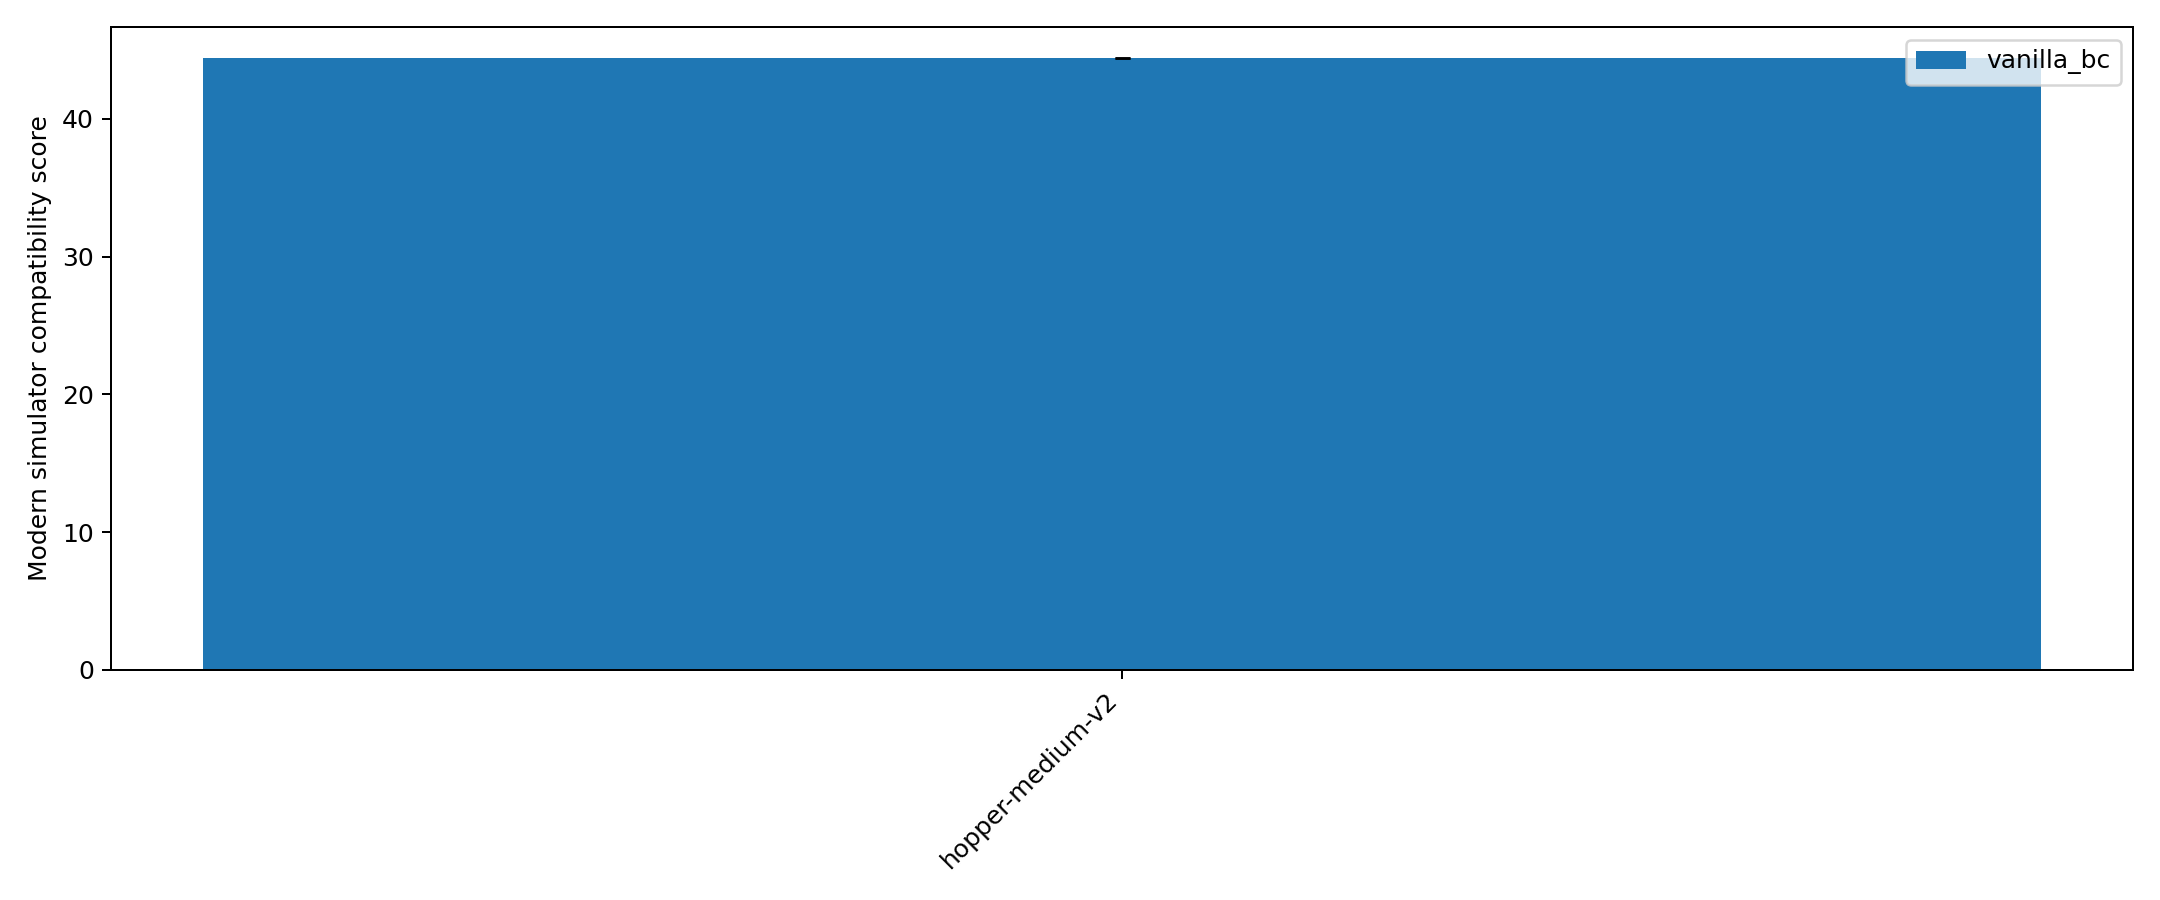

### Robustness to Observation Noise

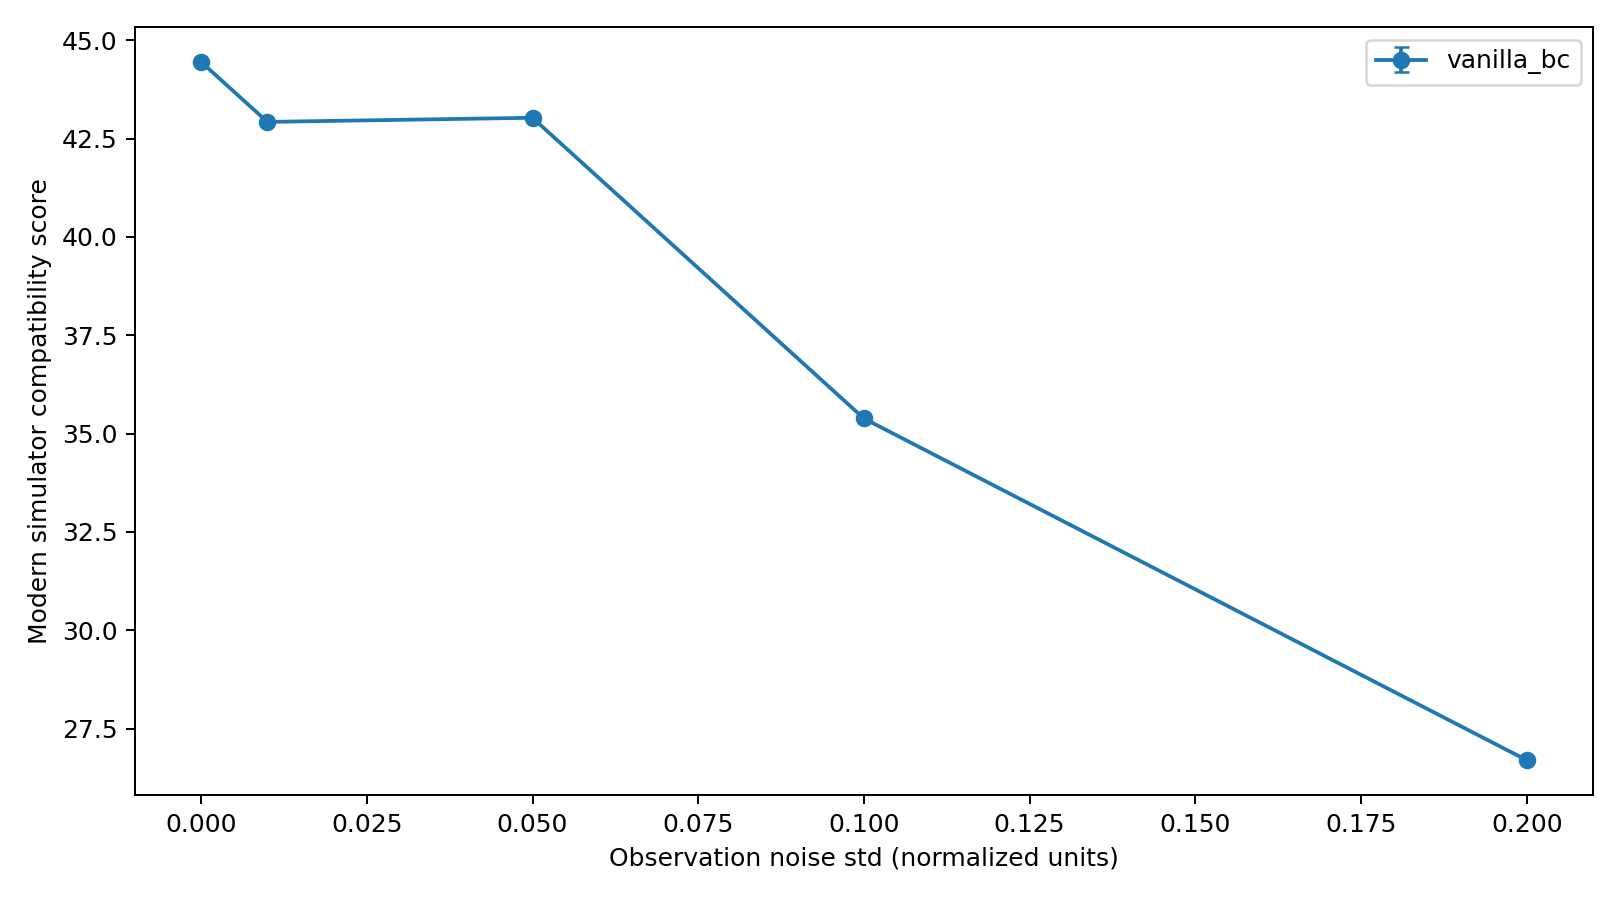

### Relative Performance Drop-off

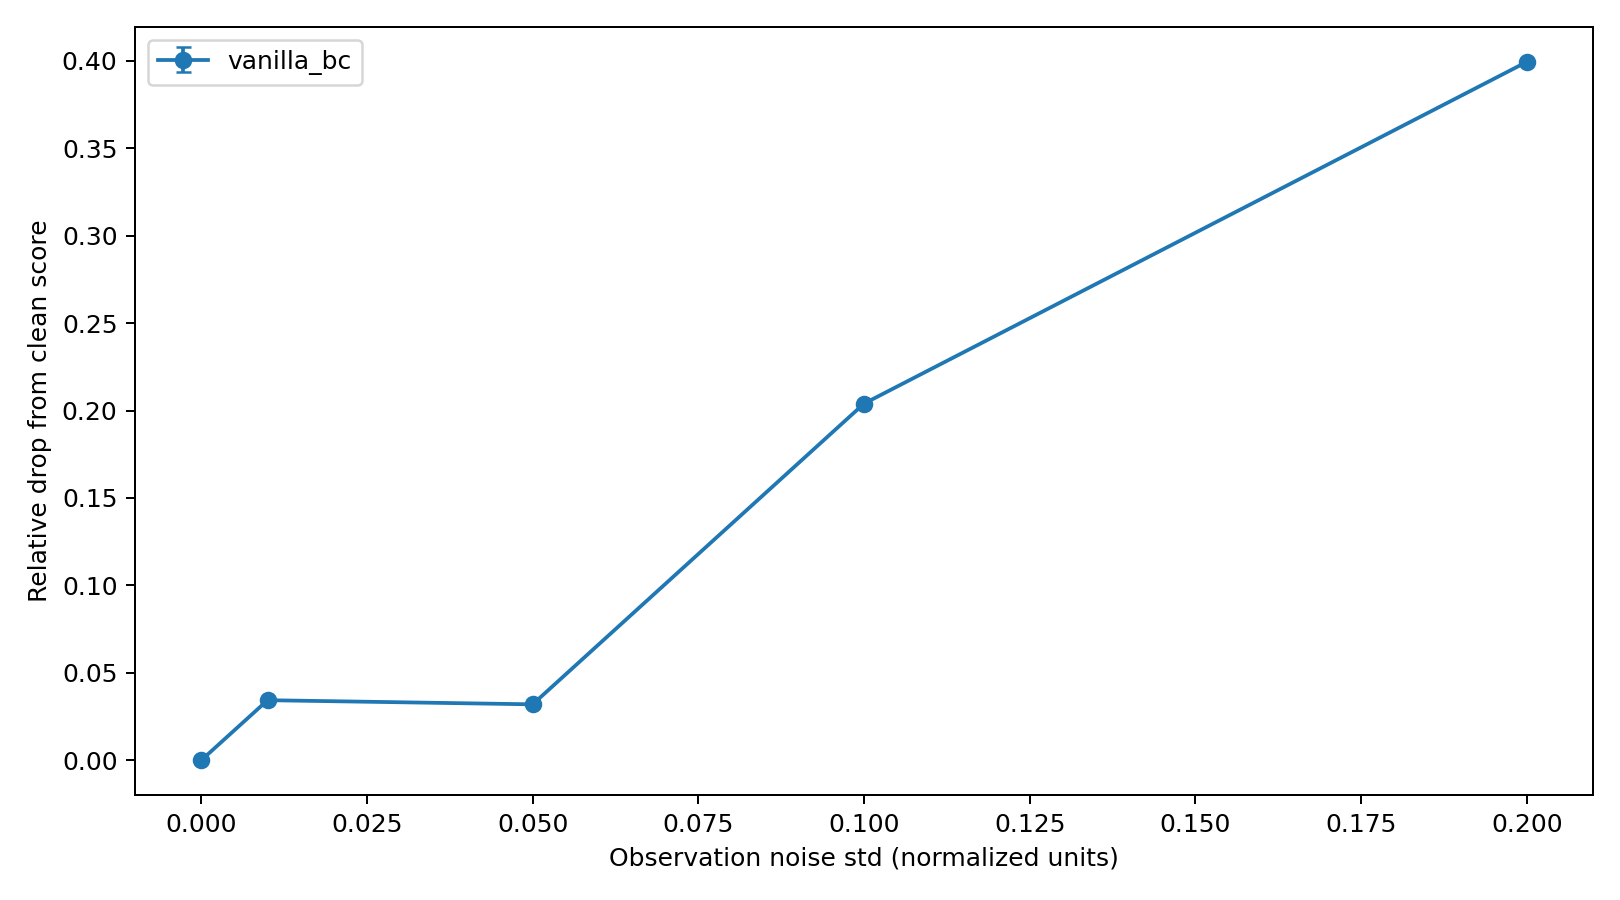

### Validation Loss

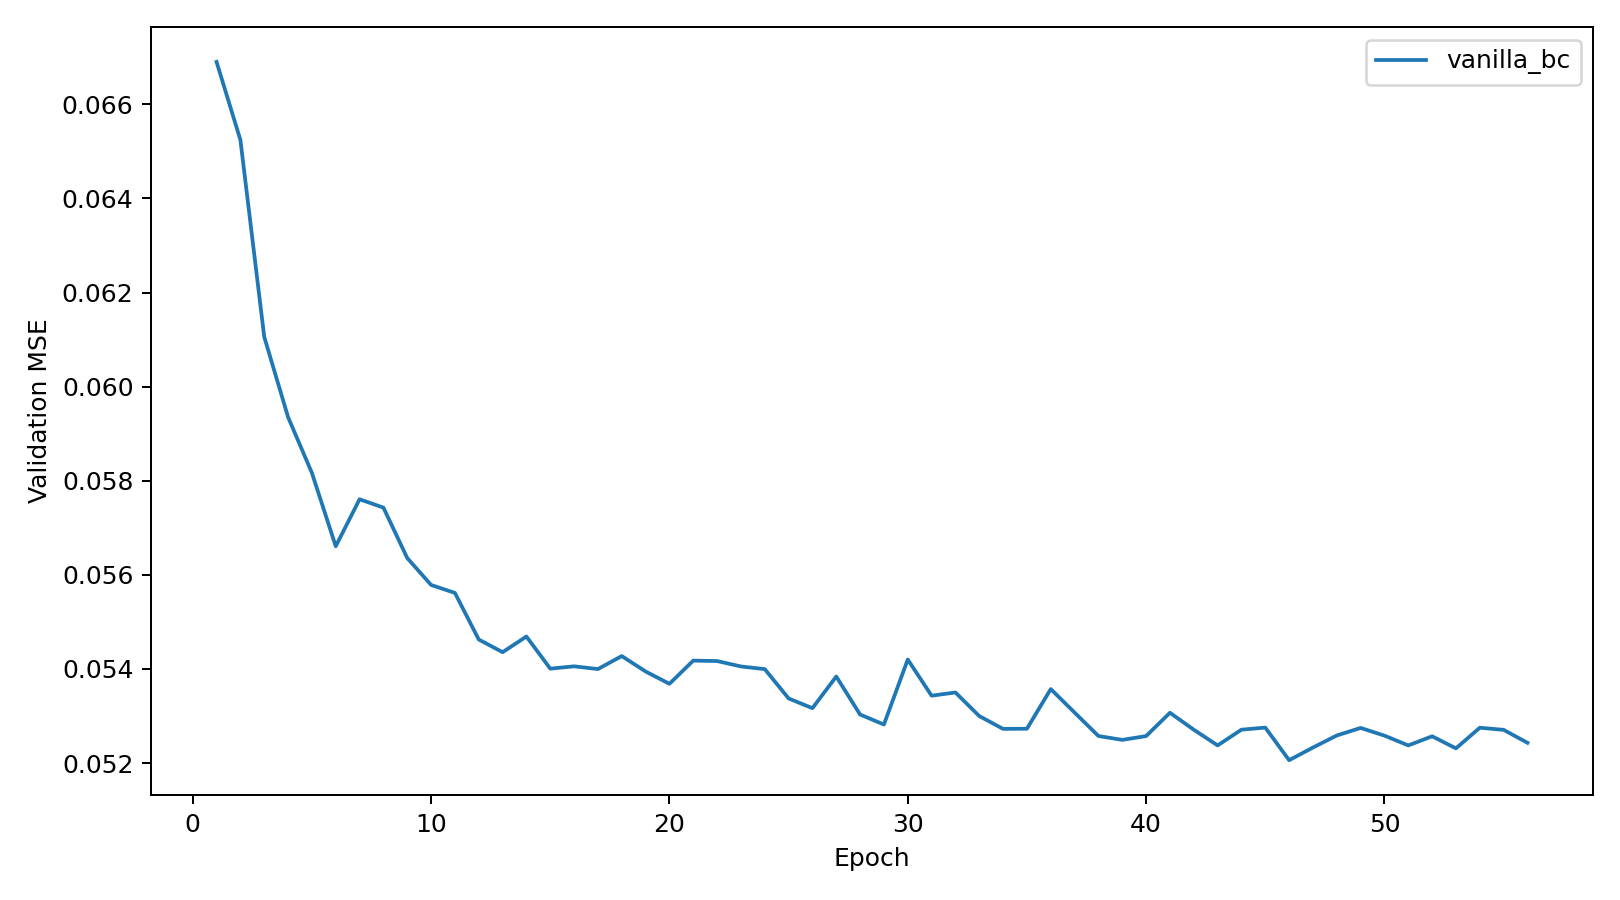

In [23]:
# SECTION: Display Saved Result Figures
from IPython.display import Image, display
from IPython.display import Markdown

INLINE_FIGURES = [
    ("Clean Scores", "clean_scores.png"),
    ("Robustness to Observation Noise", "robustness.png"),
    ("Relative Performance Drop-off", "dropoff.png"),
    ("Validation Loss", "validation_loss.png"),
]
for title, filename in INLINE_FIGURES:
    path = OUTPUT_ROOT / "figures" / filename
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}; run the Reporting cell first")
    display(Markdown(f"### {title}"))
    display(Image(filename=str(path)))


## Export and Next Session

- **Purpose:** Validate durable outputs before publishing them for resume.
- **Inputs:** Artifact directory.
- **Outputs:** Integrity summary ready for Kaggle Dataset publication.
- **Modes:** All
- **Cost:** seconds
- **Recovery:** Do not publish temporary files; rerun the owning section if a required artifact is absent.


In [24]:
# SECTION: export
temporary_files = list(OUTPUT_ROOT.rglob("*.tmp"))
assert not temporary_files, temporary_files
print("Artifact root:", OUTPUT_ROOT)
print("Publish this directory as a Kaggle Dataset, attach it next session, then set RESUME_INPUT_ROOT.")


Artifact root: /kaggle/working/latent_mixup_bc
Publish this directory as a Kaggle Dataset, attach it next session, then set RESUME_INPUT_ROOT.


## Incremental Pilot Comparison

- **Purpose:** Define a resumable helper that trains and evaluates one additional method without rerunning completed methods or earlier notebook setup.
- **Inputs:** Existing SINGLE_RUN config, prepared dataset cache, ArtifactStore, and Vanilla BC artifacts.
- **Outputs:** Reusable run_pilot_method(method) helper.
- **Modes:** SINGLE_RUN only
- **Cost:** seconds
- **Recovery:** Run the notebook through the first Reporting section once; then these pilot cells can be rerun independently.


In [25]:
# SECTION: Incremental Pilot Comparison
from dataclasses import replace

if RUN_MODE != "SINGLE_RUN":
    raise RuntimeError("Pilot requires RUN_MODE='SINGLE_RUN'")

def run_pilot_method(method):
    if method not in {"noise_bc", "input_mixup_bc", "latent_mixup_bc"}:
        raise ValueError(f"Unsupported incremental pilot method: {method}")
    pilot_config = replace(config, single_method=method)
    pilot_run = enumerate_runs(pilot_config)[0]
    train_loader, valid_loader, normalizer, train_rows, valid_rows = prepared_data(pilot_run)
    assert set(train_rows).isdisjoint(valid_rows)
    state_dim = train_loader.dataset.tensors[0].shape[1]
    action_dim = train_loader.dataset.tensors[1].shape[1]
    train_result = train_one_run(
        pilot_run, pilot_config, train_loader, valid_loader,
        state_dim, action_dim, store, normalizer=normalizer,
    )
    print(f"{method} training:", train_result)

    model, payload = load_best_policy(pilot_run, pilot_config, store)
    saved_normalizer = StateNormalizer.from_dict(payload["normalizer"])
    env = gym.make(pilot_run.env_id)
    required_episodes = pilot_config.evaluation_episodes
    for noise_std in pilot_config.noise_levels:
        current = pd.read_csv(store.episode_results_path) if store.episode_results_path.exists() else pd.DataFrame()
        completed = set()
        if not current.empty:
            match = (
                current.dataset_id.eq(pilot_run.dataset_id)
                & current.method.eq(method)
                & current.seed.eq(pilot_run.seed)
                & current.noise_std.eq(noise_std)
            )
            completed = set(current.loc[match, "episode"].astype(int))
        missing = set(range(required_episodes)) - completed
        if not missing:
            print(f"{method} noise={noise_std}: evaluation already complete")
            continue
        rows = evaluate_policy(
            env, model, saved_normalizer, pilot_run.dataset_id, method,
            pilot_run.seed, noise_std, required_episodes, pilot_run.env_id,
        )
        store.upsert_episode_rows(pd.DataFrame([row for row in rows if row["episode"] in missing]))
        print(f"{method} noise={noise_std}: added {len(missing)} episodes")
    env.close()
    return train_result


## Pilot Method: Noise BC

- **Purpose:** Train/evaluate Gaussian-noise BC for the selected dataset and seed.
- **Inputs:** Incremental pilot helper and existing artifacts.
- **Outputs:** Noise BC checkpoint, history, manifest, and episode rows.
- **Modes:** SINGLE_RUN only
- **Cost:** expensive
- **Recovery:** Rerun safely after interruption; completed training and evaluation keys are skipped.


In [26]:
# SECTION: Pilot Method: Noise BC
noise_result = run_pilot_method("noise_bc")


noise_bc training: {'status': 'complete', 'skipped': False, 'best_epoch': 47, 'best_valid_mse': 0.05516347980878147}
noise_bc noise=0.0: added 20 episodes
noise_bc noise=0.01: added 20 episodes
noise_bc noise=0.05: added 20 episodes
noise_bc noise=0.1: added 20 episodes
noise_bc noise=0.2: added 20 episodes


## Pilot Method: Input Mixup BC

- **Purpose:** Train/evaluate input-space state-action mixup BC for the selected dataset and seed.
- **Inputs:** Incremental pilot helper and existing artifacts.
- **Outputs:** Input Mixup checkpoint, history, manifest, and episode rows.
- **Modes:** SINGLE_RUN only
- **Cost:** expensive
- **Recovery:** Rerun safely after interruption; completed training and evaluation keys are skipped.


In [28]:
# SECTION: Pilot Method: Input Mixup BC
input_mixup_result = run_pilot_method("input_mixup_bc")


input_mixup_bc training: {'status': 'complete', 'skipped': False, 'best_epoch': 62, 'best_valid_mse': 0.05423142042423259}
input_mixup_bc noise=0.0: added 20 episodes
input_mixup_bc noise=0.01: added 20 episodes
input_mixup_bc noise=0.05: added 20 episodes
input_mixup_bc noise=0.1: added 20 episodes
input_mixup_bc noise=0.2: added 20 episodes


## Pilot Method: Latent Mixup BC

- **Purpose:** Train/evaluate the proposed latent-space state-action mixup BC for the selected dataset and seed.
- **Inputs:** Incremental pilot helper and existing artifacts.
- **Outputs:** Latent Mixup checkpoint, history, manifest, and episode rows.
- **Modes:** SINGLE_RUN only
- **Cost:** expensive
- **Recovery:** Rerun safely after interruption; completed training and evaluation keys are skipped.


In [29]:
# SECTION: Pilot Method: Latent Mixup BC
latent_mixup_result = run_pilot_method("latent_mixup_bc")


latent_mixup_bc training: {'status': 'complete', 'skipped': False, 'best_epoch': 51, 'best_valid_mse': 0.05248032451984777}
latent_mixup_bc noise=0.0: added 20 episodes
latent_mixup_bc noise=0.01: added 20 episodes
latent_mixup_bc noise=0.05: added 20 episodes
latent_mixup_bc noise=0.1: added 20 episodes
latent_mixup_bc noise=0.2: added 20 episodes


## Pilot Comparison Plots

- **Purpose:** Regenerate and display the four-method comparison for the selected dataset and seed.
- **Inputs:** Episode CSV and four method history CSV files.
- **Outputs:** Updated summary plus inline clean, robustness, drop-off, and validation-loss figures.
- **Modes:** SINGLE_RUN only
- **Cost:** seconds
- **Recovery:** Run any missing pilot method cell first; absent methods are left missing rather than treated as zero.


,dataset_id,method,noise_std,mean_score,std_score,seed_count,sem,ci95_low,ci95_high
0,hopper-medium-v2,input_mixup_bc,0.00,41.580441,NaN,1,NaN,NaN,NaN
1,hopper-medium-v2,input_mixup_bc,0.01,41.519356,NaN,1,NaN,NaN,NaN
2,hopper-medium-v2,input_mixup_bc,0.05,31.788575,NaN,1,NaN,NaN,NaN
3,hopper-medium-v2,input_mixup_bc,0.10,24.589841,NaN,1,NaN,NaN,NaN
4,hopper-medium-v2,input_mixup_bc,0.20,18.861607,NaN,1,NaN,NaN,NaN
5,hopper-medium-v2,latent_mixup_bc,0.00,40.559563,NaN,1,NaN,NaN,NaN
6,hopper-medium-v2,latent_mixup_bc,0.01,41.112558,NaN,1,NaN,NaN,NaN
7,hopper-medium-v2,latent_mixup_bc,0.05,38.561610,NaN,1,NaN,NaN,NaN
8,hopper-medium-v2,latent_mixup_bc,0.10,32.338661,NaN,1,NaN,NaN,NaN
9,hopper-medium-v2,latent_mixup_bc,0.20,27.539466,NaN,1,NaN,NaN,NaN


### Pilot Comparison — Clean Scores

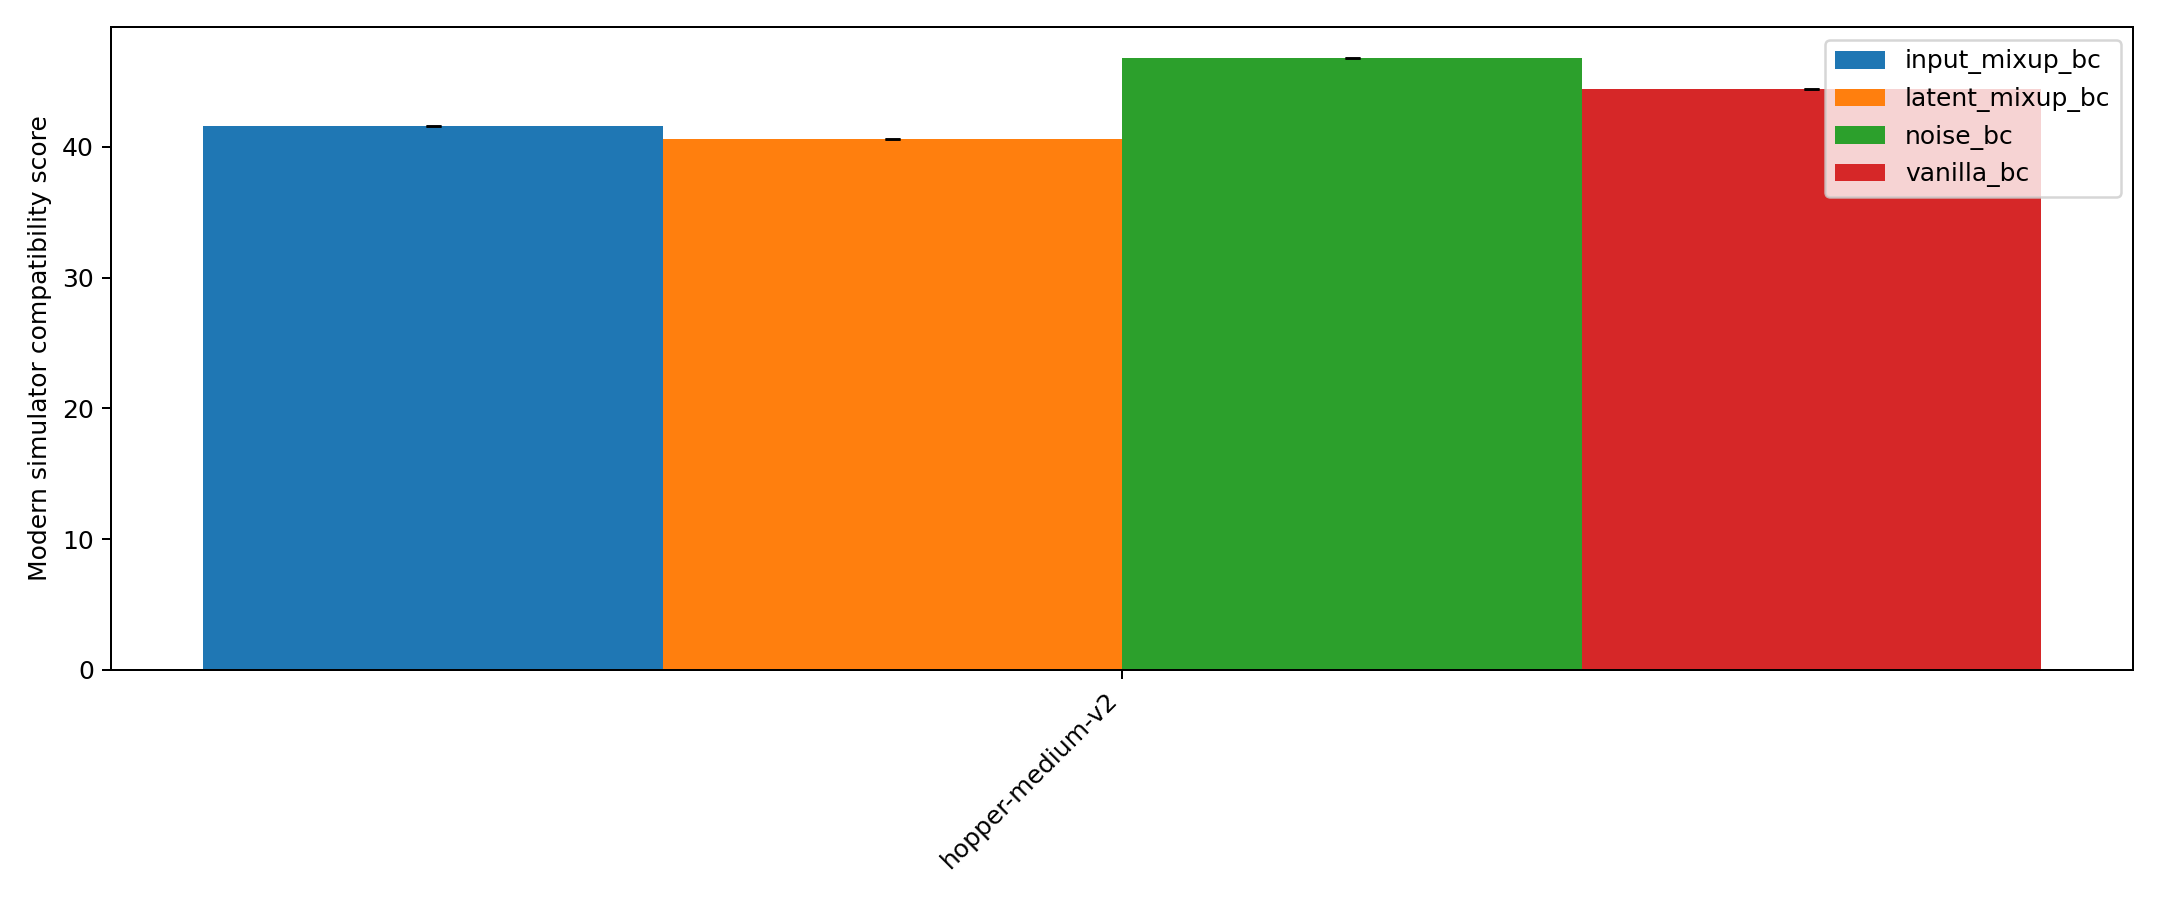

### Pilot Comparison — Robustness to Observation Noise

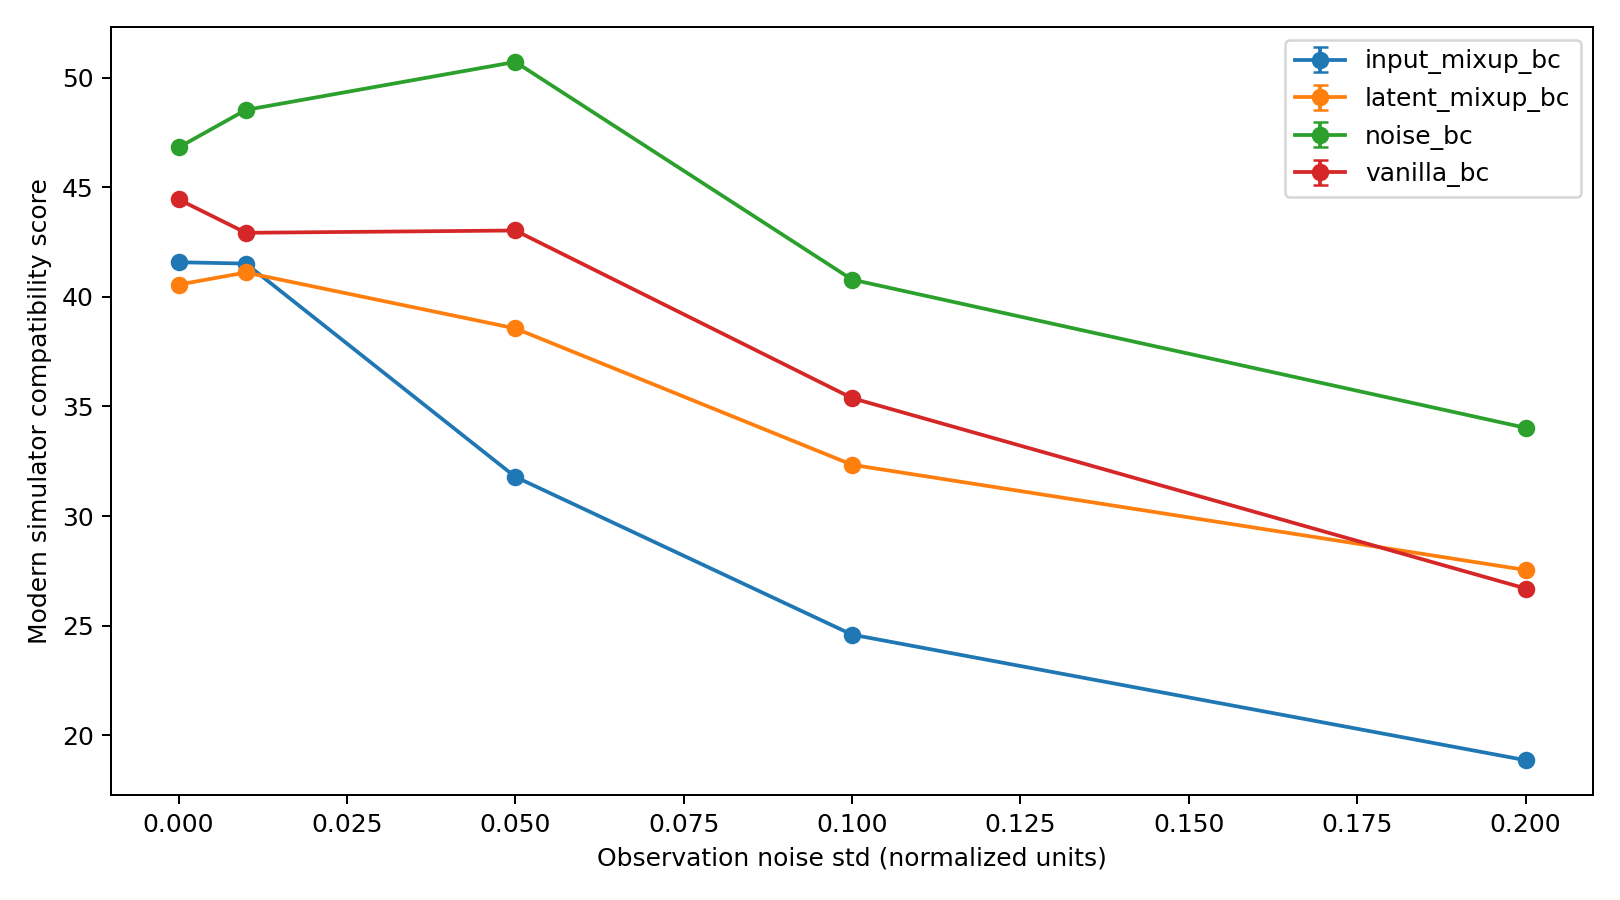

### Pilot Comparison — Relative Performance Drop-off

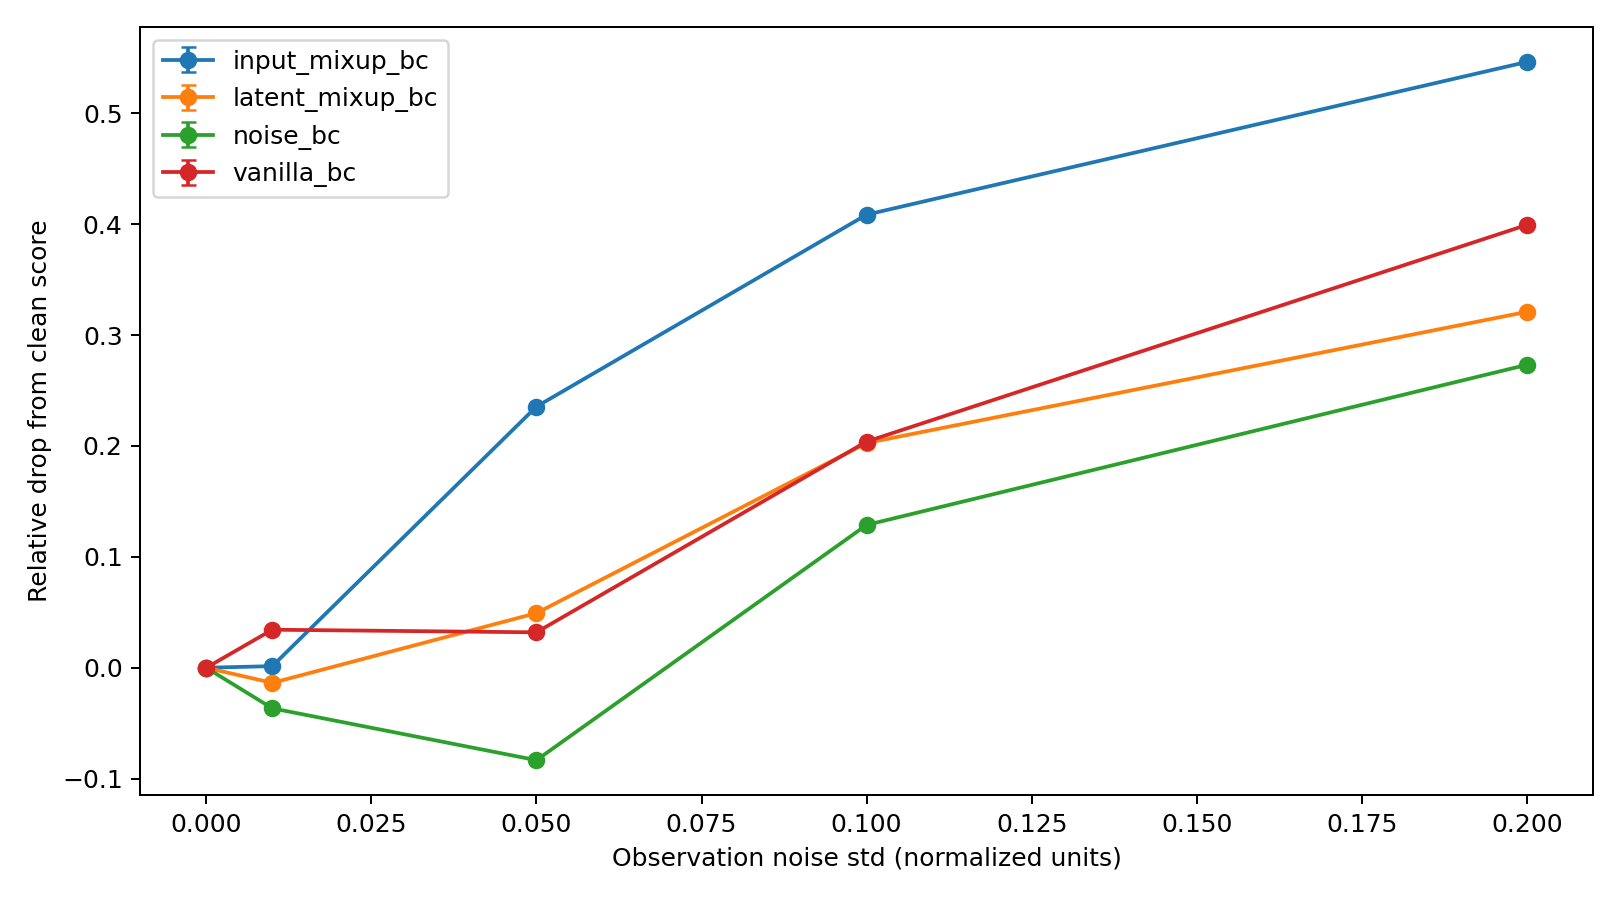

### Pilot Comparison — Validation Loss

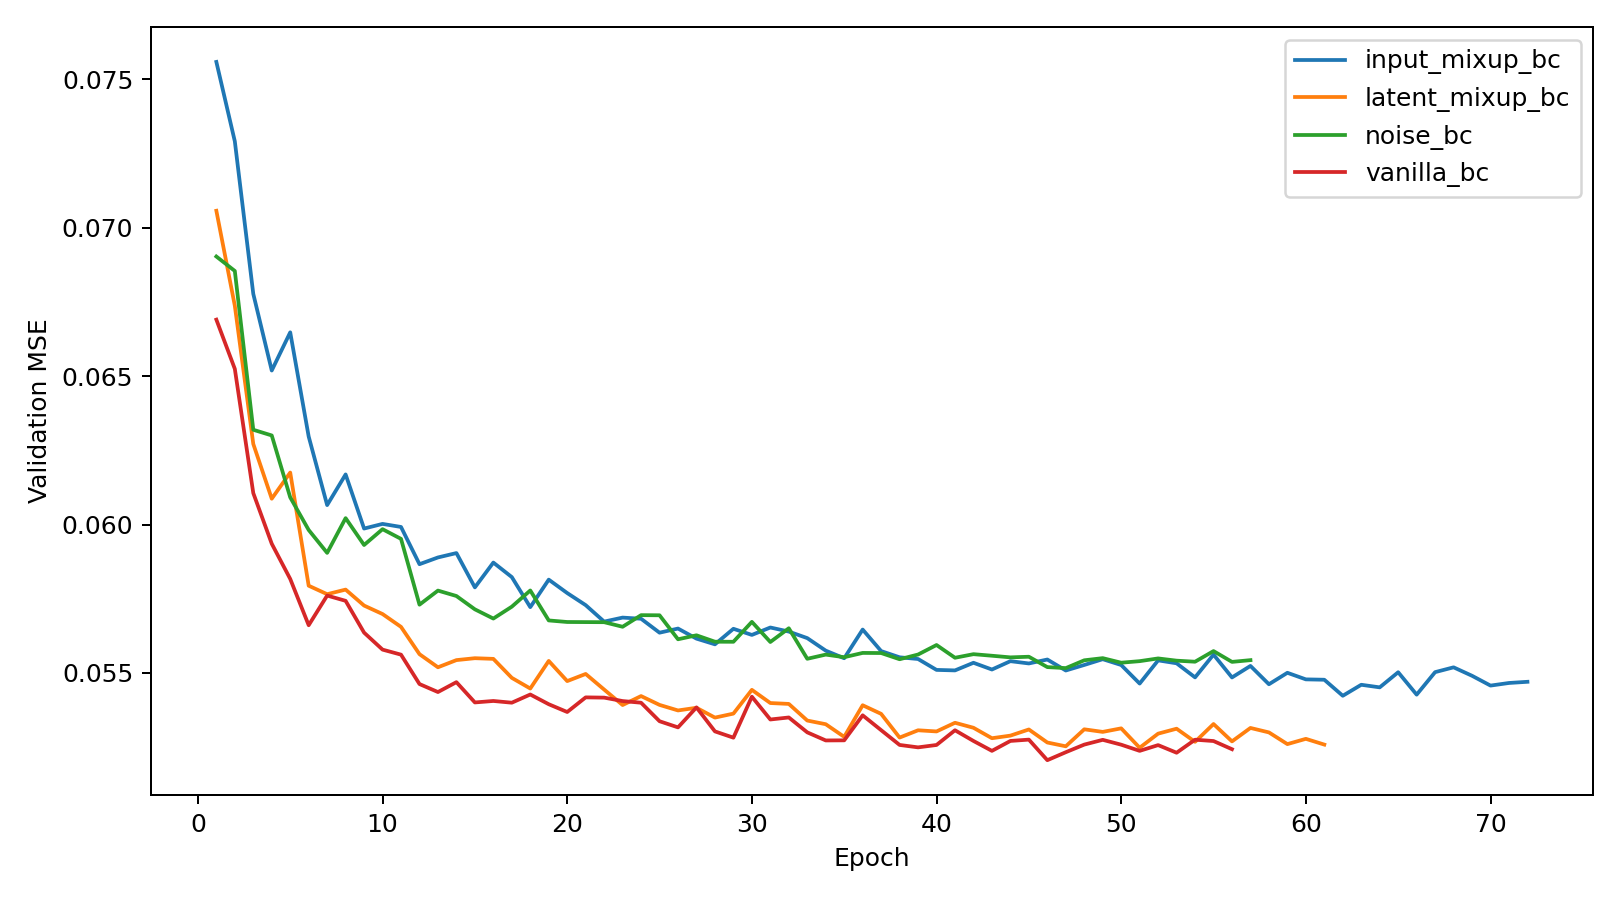

In [30]:
# SECTION: Pilot Comparison Plots
PILOT_METHODS = ["vanilla_bc", "noise_bc", "input_mixup_bc", "latent_mixup_bc"]
all_episode_results = pd.read_csv(store.episode_results_path)
pilot_episode_results = all_episode_results.loc[
    all_episode_results.dataset_id.eq(SINGLE_DATASET)
    & all_episode_results.seed.eq(SINGLE_SEED)
    & all_episode_results.method.isin(PILOT_METHODS)
].copy()
if pilot_episode_results.empty:
    raise RuntimeError("No pilot episode results found")

pilot_summary = summarize_results(pilot_episode_results)
display(pilot_summary)
available_methods = set(pilot_episode_results.method.unique())
missing_methods = set(PILOT_METHODS) - available_methods
if missing_methods:
    print("Methods still missing from comparison:", sorted(missing_methods))

pilot_histories = []
for method in PILOT_METHODS:
    path = store.history_path(SINGLE_DATASET, method, SINGLE_SEED)
    if path.exists():
        frame = pd.read_csv(path)
        frame["method"] = method
        pilot_histories.append(frame)
pilot_histories = pd.concat(pilot_histories, ignore_index=True) if pilot_histories else pd.DataFrame()

pilot_figure_paths = render_all_figures(
    pilot_episode_results, pilot_histories, OUTPUT_ROOT / "figures" / "pilot_comparison"
)
for title, filename in INLINE_FIGURES:
    path = OUTPUT_ROOT / "figures" / "pilot_comparison" / filename
    if path.exists():
        display(Markdown(f"### Pilot Comparison — {title}"))
        display(Image(filename=str(path)))


## Export and Next Session

- **Purpose:** Validate durable outputs before publishing them for resume.
- **Inputs:** Artifact directory.
- **Outputs:** Integrity summary ready for Kaggle Dataset publication.
- **Modes:** All
- **Cost:** seconds
- **Recovery:** Do not publish temporary files; rerun the owning section if a required artifact is absent.


In [31]:
# SECTION: export
temporary_files = list(OUTPUT_ROOT.rglob("*.tmp"))
assert not temporary_files, temporary_files
print("Artifact root:", OUTPUT_ROOT)
print("Publish this directory as a Kaggle Dataset, attach it next session, then set RESUME_INPUT_ROOT.")


Artifact root: /kaggle/working/latent_mixup_bc
Publish this directory as a Kaggle Dataset, attach it next session, then set RESUME_INPUT_ROOT.


## Multi-Seed Pilot

- **Purpose:** Define resumable training/evaluation helpers for seeds 1–4 across all four methods.
- **Inputs:** Existing dataset cache, ArtifactStore, model modules, and completed seed 0 artifacts.
- **Outputs:** run_method_seed and run_seed helpers.
- **Modes:** SINGLE_RUN only
- **Cost:** seconds
- **Recovery:** Run one seed cell per Kaggle session if needed; every method/noise/episode resumes independently.


In [33]:
# SECTION: Multi-Seed Pilot
SEEDS = [0, 1, 2, 3, 4]
MULTI_SEED_METHODS = ["vanilla_bc", "noise_bc", "input_mixup_bc", "latent_mixup_bc"]

if RUN_MODE != "SINGLE_RUN":
    raise RuntimeError("Multi-seed pilot requires RUN_MODE='SINGLE_RUN'")

def run_method_seed(method, seed):
    if method not in MULTI_SEED_METHODS:
        raise ValueError(f"Unknown method: {method}")
    if seed not in SEEDS:
        raise ValueError(f"Seed must be one of {SEEDS}")
    method_config = replace(config, single_method=method, single_seed=seed)
    method_run = enumerate_runs(method_config)[0]
    train_loader, valid_loader, normalizer, train_rows, valid_rows = prepared_data(method_run)
    assert set(train_rows).isdisjoint(valid_rows)
    state_dim = train_loader.dataset.tensors[0].shape[1]
    action_dim = train_loader.dataset.tensors[1].shape[1]
    train_result = train_one_run(
        method_run, method_config, train_loader, valid_loader,
        state_dim, action_dim, store, normalizer=normalizer,
    )
    print(f"seed={seed} method={method} training:", train_result)

    model, payload = load_best_policy(method_run, method_config, store)
    saved_normalizer = StateNormalizer.from_dict(payload["normalizer"])
    env = gym.make(method_run.env_id)
    required_episodes = method_config.evaluation_episodes
    for noise_std in method_config.noise_levels:
        current = pd.read_csv(store.episode_results_path) if store.episode_results_path.exists() else pd.DataFrame()
        completed = set()
        if not current.empty:
            match = (
                current.dataset_id.eq(method_run.dataset_id)
                & current.method.eq(method)
                & current.seed.eq(seed)
                & current.noise_std.eq(noise_std)
            )
            completed = set(current.loc[match, "episode"].astype(int))
        missing = set(range(required_episodes)) - completed
        if not missing:
            print(f"seed={seed} method={method} noise={noise_std}: complete")
            continue
        rows = evaluate_policy(
            env, model, saved_normalizer, method_run.dataset_id, method,
            seed, noise_std, required_episodes, method_run.env_id,
        )
        new_rows = [row for row in rows if row["episode"] in missing]
        store.upsert_episode_rows(pd.DataFrame(new_rows))
        print(f"seed={seed} method={method} noise={noise_std}: added {len(new_rows)} episodes")
    env.close()
    return train_result

def run_seed(seed):
    results = {}
    for method in MULTI_SEED_METHODS:
        results[method] = run_method_seed(method, seed)
    return results


In [34]:
# SECTION: Pilot Seed 1
seed_1_results = run_seed(1)


seed=1 method=vanilla_bc training: {'status': 'complete', 'skipped': False, 'best_epoch': 50, 'best_valid_mse': 0.052176761951239915}
seed=1 method=vanilla_bc noise=0.0: added 20 episodes
seed=1 method=vanilla_bc noise=0.01: added 20 episodes
seed=1 method=vanilla_bc noise=0.05: added 20 episodes
seed=1 method=vanilla_bc noise=0.1: added 20 episodes
seed=1 method=vanilla_bc noise=0.2: added 20 episodes
seed=1 method=noise_bc training: {'status': 'complete', 'skipped': False, 'best_epoch': 35, 'best_valid_mse': 0.05555819320676223}
seed=1 method=noise_bc noise=0.0: added 20 episodes
seed=1 method=noise_bc noise=0.01: added 20 episodes
seed=1 method=noise_bc noise=0.05: added 20 episodes
seed=1 method=noise_bc noise=0.1: added 20 episodes
seed=1 method=noise_bc noise=0.2: added 20 episodes
seed=1 method=input_mixup_bc training: {'status': 'complete', 'skipped': False, 'best_epoch': 30, 'best_valid_mse': 0.0555223928129125}
seed=1 method=input_mixup_bc noise=0.0: added 20 episodes
seed=1 

In [35]:
# SECTION: Pilot Seed 2
seed_2_results = run_seed(2)


seed=2 method=vanilla_bc training: {'status': 'complete', 'skipped': False, 'best_epoch': 31, 'best_valid_mse': 0.053157735684954875}
seed=2 method=vanilla_bc noise=0.0: added 20 episodes
seed=2 method=vanilla_bc noise=0.01: added 20 episodes
seed=2 method=vanilla_bc noise=0.05: added 20 episodes
seed=2 method=vanilla_bc noise=0.1: added 20 episodes
seed=2 method=vanilla_bc noise=0.2: added 20 episodes
seed=2 method=noise_bc training: {'status': 'complete', 'skipped': False, 'best_epoch': 45, 'best_valid_mse': 0.055910761487270824}
seed=2 method=noise_bc noise=0.0: added 20 episodes
seed=2 method=noise_bc noise=0.01: added 20 episodes
seed=2 method=noise_bc noise=0.05: added 20 episodes
seed=2 method=noise_bc noise=0.1: added 20 episodes
seed=2 method=noise_bc noise=0.2: added 20 episodes
seed=2 method=input_mixup_bc training: {'status': 'complete', 'skipped': False, 'best_epoch': 45, 'best_valid_mse': 0.05524945248878098}
seed=2 method=input_mixup_bc noise=0.0: added 20 episodes
seed=

In [36]:
# SECTION: Pilot Seed 3
seed_3_results = run_seed(3)


seed=3 method=vanilla_bc training: {'status': 'complete', 'skipped': False, 'best_epoch': 63, 'best_valid_mse': 0.05213061505910374}
seed=3 method=vanilla_bc noise=0.0: added 20 episodes
seed=3 method=vanilla_bc noise=0.01: added 20 episodes
seed=3 method=vanilla_bc noise=0.05: added 20 episodes
seed=3 method=vanilla_bc noise=0.1: added 20 episodes
seed=3 method=vanilla_bc noise=0.2: added 20 episodes
seed=3 method=noise_bc training: {'status': 'complete', 'skipped': False, 'best_epoch': 74, 'best_valid_mse': 0.054875732871066916}
seed=3 method=noise_bc noise=0.0: added 20 episodes
seed=3 method=noise_bc noise=0.01: added 20 episodes
seed=3 method=noise_bc noise=0.05: added 20 episodes
seed=3 method=noise_bc noise=0.1: added 20 episodes
seed=3 method=noise_bc noise=0.2: added 20 episodes
seed=3 method=input_mixup_bc training: {'status': 'complete', 'skipped': False, 'best_epoch': 34, 'best_valid_mse': 0.05522904312720241}
seed=3 method=input_mixup_bc noise=0.0: added 20 episodes
seed=3

In [37]:
# SECTION: Pilot Seed 4
seed_4_results = run_seed(4)


seed=4 method=vanilla_bc training: {'status': 'complete', 'skipped': False, 'best_epoch': 56, 'best_valid_mse': 0.05191859087815802}
seed=4 method=vanilla_bc noise=0.0: added 20 episodes
seed=4 method=vanilla_bc noise=0.01: added 20 episodes
seed=4 method=vanilla_bc noise=0.05: added 20 episodes
seed=4 method=vanilla_bc noise=0.1: added 20 episodes
seed=4 method=vanilla_bc noise=0.2: added 20 episodes
seed=4 method=noise_bc training: {'status': 'complete', 'skipped': False, 'best_epoch': 63, 'best_valid_mse': 0.05501916575720553}
seed=4 method=noise_bc noise=0.0: added 20 episodes
seed=4 method=noise_bc noise=0.01: added 20 episodes
seed=4 method=noise_bc noise=0.05: added 20 episodes
seed=4 method=noise_bc noise=0.1: added 20 episodes
seed=4 method=noise_bc noise=0.2: added 20 episodes
seed=4 method=input_mixup_bc training: {'status': 'complete', 'skipped': False, 'best_epoch': 66, 'best_valid_mse': 0.054125169314221976}
seed=4 method=input_mixup_bc noise=0.0: added 20 episodes
seed=4

## Multi-Seed Aggregate Plots

- **Purpose:** Aggregate completed seeds without imputing missing runs and display uncertainty-aware comparisons.
- **Inputs:** Episode CSV and history CSV files for seeds 0–4.
- **Outputs:** Coverage table, mean/std/CI table, and four inline aggregate figures.
- **Modes:** SINGLE_RUN only
- **Cost:** seconds
- **Recovery:** This cell can run after any seed; incomplete seeds remain absent and are reported in coverage.


### Completed training seeds by method

,completed_seed_count
method,
vanilla_bc,5
noise_bc,5
input_mixup_bc,5
latent_mixup_bc,5


### Multi-seed summary

,dataset_id,method,noise_std,mean_score,std_score,seed_count,sem,ci95_low,ci95_high
0,hopper-medium-v2,input_mixup_bc,0.00,43.547058,4.208569,5,1.882129,39.858085,47.236032
1,hopper-medium-v2,input_mixup_bc,0.01,42.970550,4.493692,5,2.009640,39.031655,46.909445
2,hopper-medium-v2,input_mixup_bc,0.05,37.712052,4.276256,5,1.912400,33.963748,41.460356
3,hopper-medium-v2,input_mixup_bc,0.10,29.738928,3.015659,5,1.348643,27.095587,32.382269
4,hopper-medium-v2,input_mixup_bc,0.20,23.678477,4.254090,5,1.902487,19.949602,27.407351
5,hopper-medium-v2,latent_mixup_bc,0.00,41.202281,0.897372,5,0.401317,40.415700,41.988862
6,hopper-medium-v2,latent_mixup_bc,0.01,41.595464,0.749760,5,0.335303,40.938270,42.252658
7,hopper-medium-v2,latent_mixup_bc,0.05,35.540807,2.324573,5,1.039581,33.503229,37.578385
8,hopper-medium-v2,latent_mixup_bc,0.10,30.026671,2.239158,5,1.001382,28.063963,31.989380
9,hopper-medium-v2,latent_mixup_bc,0.20,27.568216,1.344391,5,0.601230,26.389806,28.746627


### Multi-Seed — Clean Scores

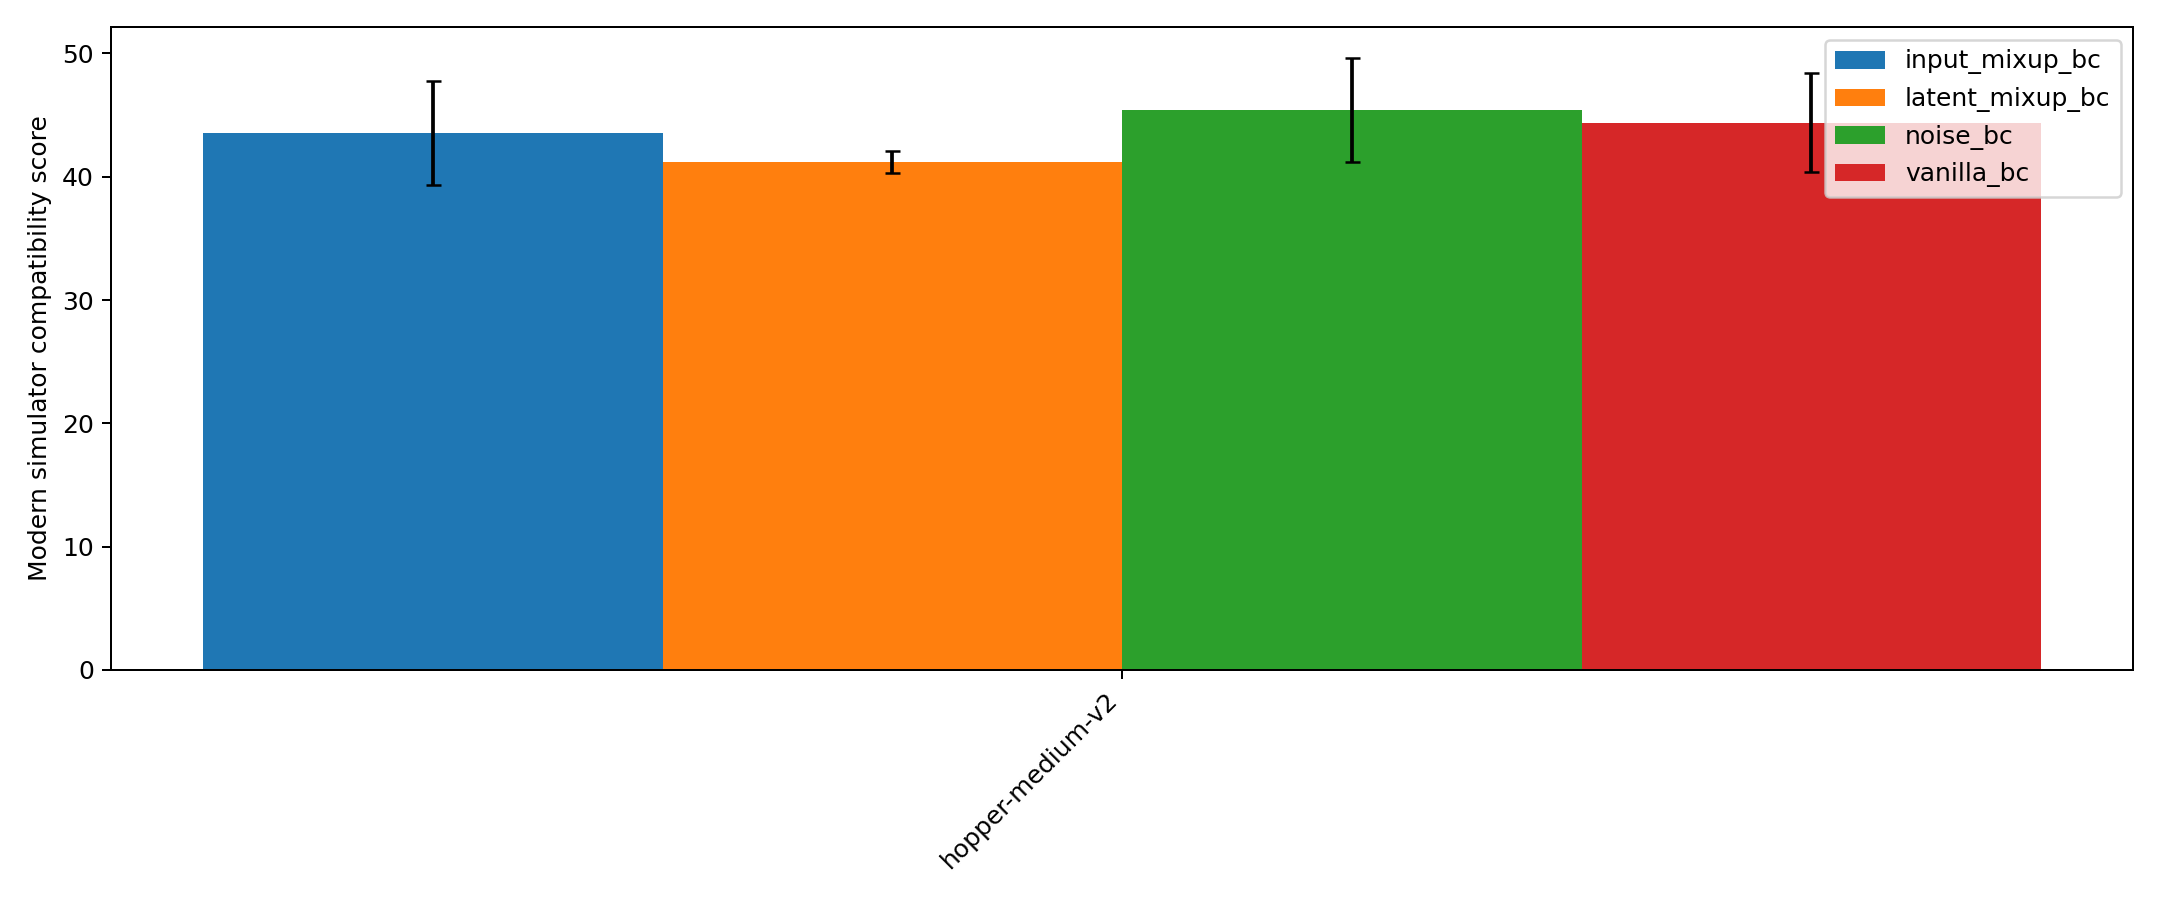

### Multi-Seed — Robustness to Observation Noise

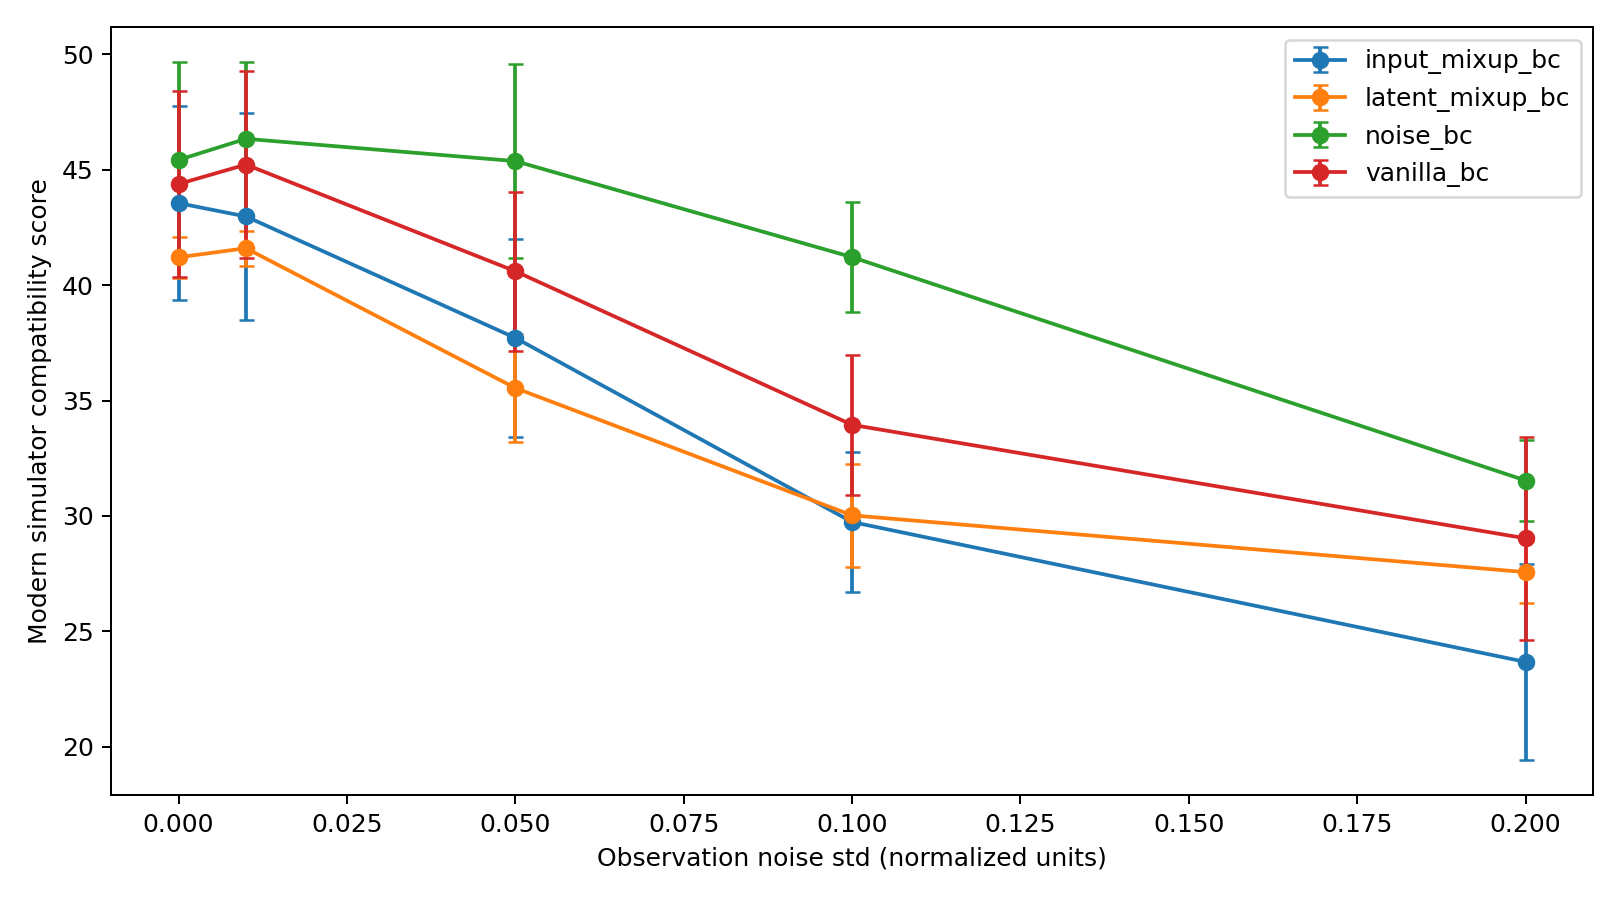

### Multi-Seed — Relative Performance Drop-off

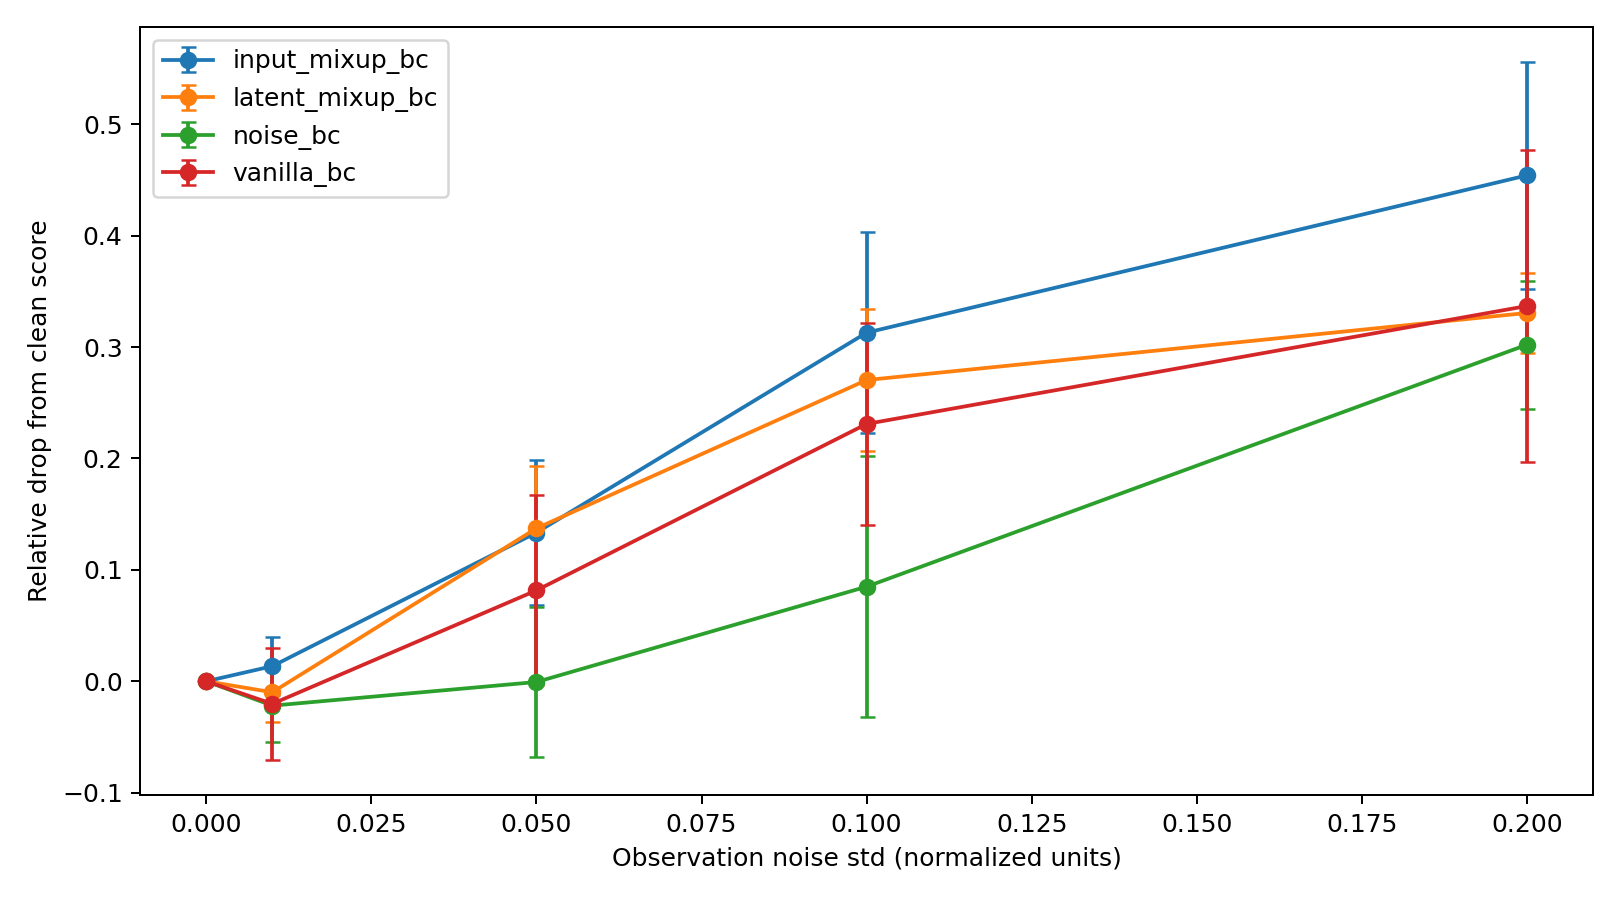

### Multi-Seed — Validation Loss

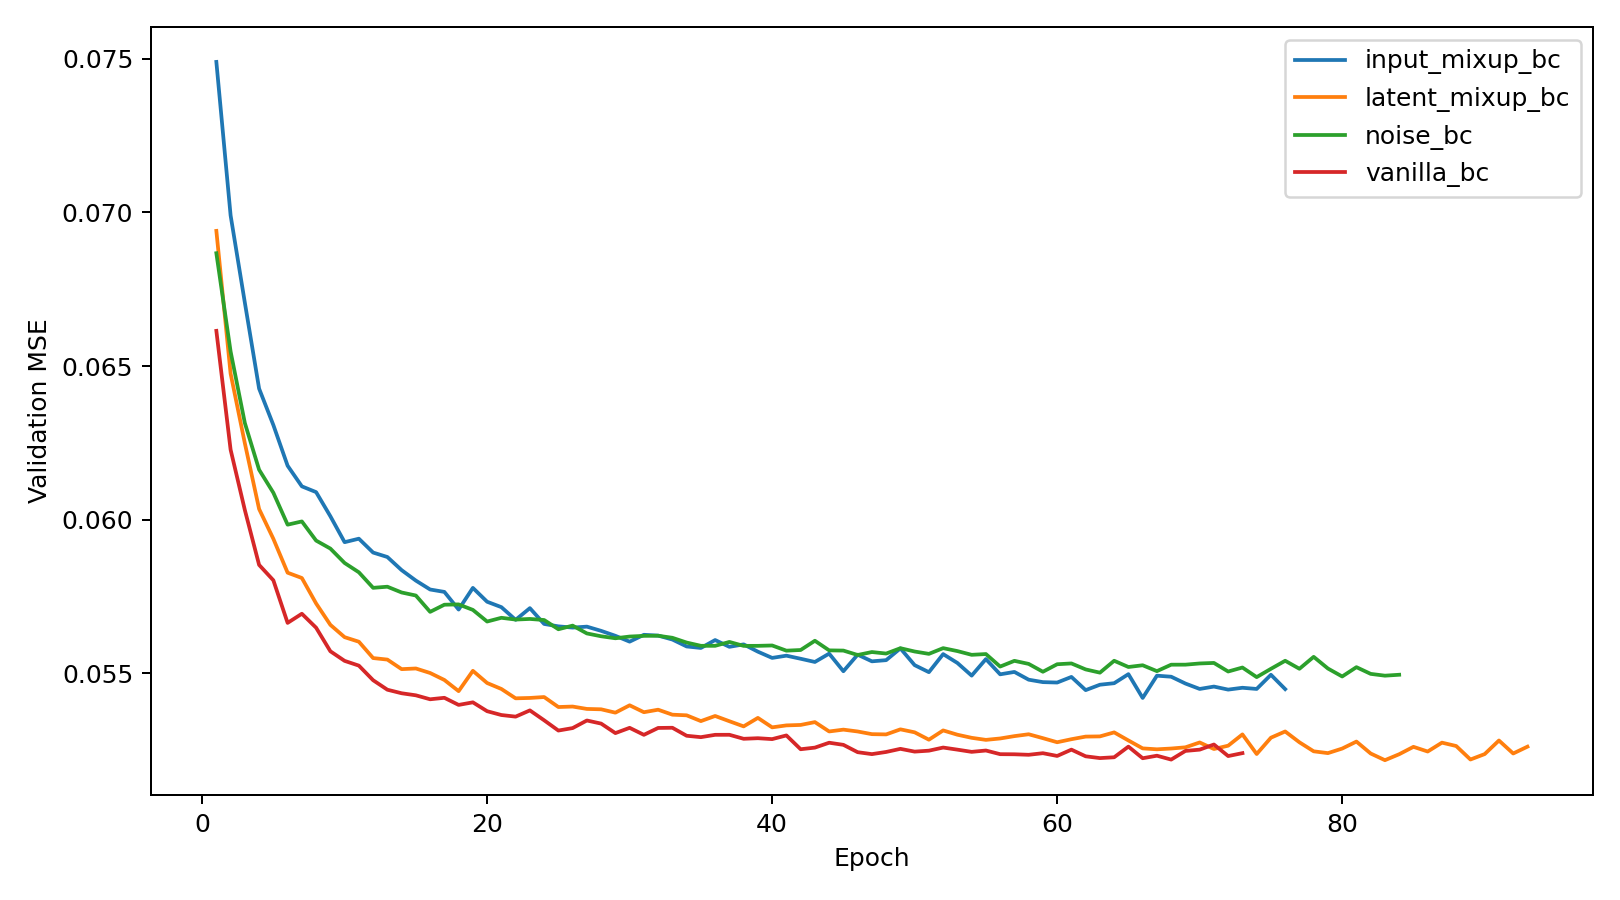

In [38]:
# SECTION: Multi-Seed Aggregate Plots
all_episode_results = pd.read_csv(store.episode_results_path)
multi_seed_episodes = all_episode_results.loc[
    all_episode_results.dataset_id.eq(SINGLE_DATASET)
    & all_episode_results.seed.isin(SEEDS)
    & all_episode_results.method.isin(MULTI_SEED_METHODS)
].copy()

clean_rows = multi_seed_episodes.loc[multi_seed_episodes.noise_std.eq(0.0)]
completed_seed_count = clean_rows.groupby("method")["seed"].nunique().reindex(MULTI_SEED_METHODS, fill_value=0)
display(Markdown("### Completed training seeds by method"))
display(completed_seed_count.rename("completed_seed_count").to_frame())

multi_seed_summary = summarize_results(multi_seed_episodes)
display(Markdown("### Multi-seed summary"))
display(multi_seed_summary)

multi_seed_histories = []
for seed in SEEDS:
    for method in MULTI_SEED_METHODS:
        path = store.history_path(SINGLE_DATASET, method, seed)
        if path.exists():
            frame = pd.read_csv(path)
            frame["method"] = method
            frame["seed"] = seed
            multi_seed_histories.append(frame)
multi_seed_histories = pd.concat(multi_seed_histories, ignore_index=True) if multi_seed_histories else pd.DataFrame()

aggregate_dir = OUTPUT_ROOT / "figures" / "multi_seed_comparison"
aggregate_paths = render_all_figures(multi_seed_episodes, multi_seed_histories, aggregate_dir)
for title, filename in INLINE_FIGURES:
    path = aggregate_dir / filename
    if path.exists():
        display(Markdown(f"### Multi-Seed — {title}"))
        display(Image(filename=str(path)))


In [39]:
# SECTION: export
temporary_files = list(OUTPUT_ROOT.rglob("*.tmp"))
assert not temporary_files, temporary_files
print("Artifact root:", OUTPUT_ROOT)
print("Publish this directory as a Kaggle Dataset, attach it next session, then set RESUME_INPUT_ROOT.")


Artifact root: /kaggle/working/latent_mixup_bc
Publish this directory as a Kaggle Dataset, attach it next session, then set RESUME_INPUT_ROOT.
